# Full Pipeline

This notebook will:
 - Inspect the data
 - Train the 6 models across 5 different seeds in a closed set scenario
 - Evaluate closed set performance
 - Calibrate open set methods (OpenMax / OpenPCA--Qmin)
 - Evaluate open set performance (non threshold based - ROC curves and threshold based - F1, FPR@TPR, etc.)
 - Predict the result of the best model on the CanopyRS extracted patches

Input data:
 - known and unknown species patches
 - CanopyRS segmented ITCs shapefile


## Drive Mount

This project was elaborated and ran on Google Colab. If the intention is to run locally, ignore this and follow
steps described on 'https://github.com/gustavo-rossi-INPE/open_set_classification'

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount = True)

Mounted at /content/drive/


## Dataset inspection

In [ ]:
import os
from collections import defaultdict

base_path = "/content/drive/MyDrive/TCC/patches/split_data"

def count_images_in_species_folder(folder_path):
    """Conta arquivos .png dentro de uma pasta."""
    return len([f for f in os.listdir(folder_path) if f.lower().endswith(".png")])

known_counts = defaultdict(int)
unknown_counts = defaultdict(int)

# ---------- KNOWN ----------
known_path = os.path.join(base_path, "known")

for split in ["train", "val"]:
    split_path = os.path.join(known_path, split)

    if not os.path.exists(split_path):
        continue

    for species in os.listdir(split_path):
        species_path = os.path.join(split_path, species)

        if os.path.isdir(species_path):
            n_imgs = count_images_in_species_folder(species_path)
            known_counts[species] += n_imgs

# ---------- UNKNOWN ----------
unknown_path = os.path.join(base_path, "unknown")

if os.path.exists(unknown_path):
    for species in os.listdir(unknown_path):
        species_path = os.path.join(unknown_path, species)

        if os.path.isdir(species_path):
            n_imgs = count_images_in_species_folder(species_path)
            unknown_counts[species] = n_imgs

# ---------- RESULTADOS ----------
print("===== KNOWN (train + val) =====")
total_known = 0
for species, count in sorted(known_counts.items()):
    print(f"{species}: {count}")
    total_known += count

print(f"\nTotal KNOWN: {total_known}")

print("\n===== UNKNOWN =====")
total_unknown = 0
for species, count in sorted(unknown_counts.items()):
    print(f"{species}: {count}")
    total_unknown += count

print(f"\nTotal UNKNOWN: {total_unknown}")

===== KNOWN (train + val) =====
Byrsonima laxiflora: 43
Copaifera langsdorffii: 121
Maprounea guianensis: 29
Ocotea corymbosa: 43
Persea willdernovii: 26
Syagrus romanzoffiana: 23
Symplocos revoluta: 17

Total KNOWN: 302

===== UNKNOWN =====
Anadenanthera peregrina: 9
Bowdichia virgilioides: 1
Clethra scabra: 1
Croton floribundus: 9
Esenbeckia grandiflora: 1
Mabea fistulifera: 4
Machaerium acutifolium: 5
Machaerium brasiliense: 6
Magnolia ovata: 6
Moquiniastrum polymorphum: 3
Myrsine cf. umbellata: 2
Pinus sp: 5
Piptocarpha axilaris: 1
Platypodium elegans: 2
Pouteria ramiflora: 8
Terminalia glabrescens: 2
Vochysia tucanorum: 2
Xylopia sp: 2
cf. Tapirira guianensis: 10

Total UNKNOWN: 79


# Train models

In [ ]:
# ============================================================
# CLOSED-SET RUNNER
# 5 Seeds (0-4) para média robusta
# ============================================================

import os, json, random, time, traceback
import numpy as np
import pandas as pd
from typing import Dict, List

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms import InterpolationMode

from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Import TIMM
import timm

# -----------------------
# 0) CONFIG GERAL
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train configurations
IMG_SIZE_DEFAULT = 512
BATCH_SIZE = 16
NUM_EPOCHS = 50
WARMUP_EPOCHS = 5
LR = 1e-4
PATIENCE = 15

# >>> Some more setup (freeze head for first 5 epochs, then liberate the backbone to be trained)
FREEZE_HEAD_EPOCHS = 5
LR_HEAD = 1e-3
WARMUP_EPOCHS_HEAD = 1
RESET_PATIENCE_ON_UNFREEZE = True

# >>> DADOS <<<
USE_WEIGHTED_SAMPLER = True
USE_AMP = True
SEEDS = [0, 1, 2, 3, 4]  # 5 Seeds 

train_dir = "/content/drive/MyDrive/data/split_data/known/train" # substitute if needed
val_dir   = "/content/drive/MyDrive/data/split_data/known/val"

save_dir = "/content/drive/MyDrive/outputs/closedset"

os.makedirs(save_dir, exist_ok=True)
results_csv = os.path.join(save_dir, f"results_closedset.csv")

print(f"Device: {device}")
print(f"Save dir: {save_dir}")

# -----------------------
# 1) REPRODUTIBILIDADE
# -----------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

class RandomRotate90:
    def __call__(self, img):
        return img.rotate(90 * random.randint(0, 3))

def make_transforms(img_size: int):
    train_t = transforms.Compose([
        # transforms.Resize(
        #     (img_size, img_size),
        #     interpolation=InterpolationMode.BICUBIC,
        #     antialias=True
        # ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        RandomRotate90(),
        transforms.ToTensor(),
       # CopyTransform(n_copies=10),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_t = transforms.Compose([
        # transforms.Resize(
        #     (img_size, img_size),
        #     interpolation=InterpolationMode.BICUBIC,
        #     antialias=True
        # ),
        transforms.ToTensor(),
       # CopyTransform(n_copies=10),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_t, val_t
# -----------------------
# 3) DADOS & LOADERS
# -----------------------
base_train_ds = ImageFolder(train_dir, transform=transforms.ToTensor())
class_names = base_train_ds.classes
num_classes = len(class_names)

def _make_weighted_sampler(train_ds: ImageFolder, seed: int) -> WeightedRandomSampler:
    targets = np.array(train_ds.targets, dtype=np.int64)
    class_counts = np.bincount(targets, minlength=num_classes).astype(np.float64)
    class_counts[class_counts == 0] = 1.0
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[targets]

    g = torch.Generator()
    g.manual_seed(seed)

    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
        generator=g
    )

def make_loaders(seed: int, img_size: int):
    train_t, val_t = make_transforms(img_size)
    train_ds = ImageFolder(train_dir, transform=train_t)
    val_ds   = ImageFolder(val_dir, transform=val_t)

    g = torch.Generator().manual_seed(seed)

    if USE_WEIGHTED_SAMPLER:
        sampler = _make_weighted_sampler(train_ds, seed)
        shuffle = False
    else:
        sampler = None
        shuffle = True

    loader_args = dict(num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=g, persistent_workers=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler, drop_last=False, **loader_args)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)

    return train_loader, val_loader

# -----------------------
# 4) MODEL FACTORY INTELIGENTE (CORREÇÃO AQUI)
# -----------------------
def get_weight_decay(model_name: str) -> float:
    # ViTs precisam de mais WD para evitar overfitting
    if any(k in model_name for k in ["vit", "eva", "dino", "swin", "deit"]):
        return 0.05
    return 1e-4

def create_model_safe(model_name: str, num_classes: int, img_size: int):
    print(f"Creating model: {model_name}...")
    try:
        # Tentativa 1: Passar img_size (Transformers precisam disso para interpolar pos_embed)
        model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes,
            img_size=img_size
        )
    except TypeError:
        # Tentativa 2: Se der erro de argumento (ex: ResNet), chama sem img_size
        # print(f" -> '{model_name}' não aceita img_size no init. Criando padrão...")
        model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )

    return model

# -----------------------
# 5) FREEZE / UNFREEZE
# -----------------------
def get_head_module(model: nn.Module) -> nn.Module:
    if hasattr(model, "get_classifier"): return model.get_classifier()
    for attr in ["fc", "classifier", "head"]:
        if hasattr(model, attr): return getattr(model, attr)
    # Última tentativa: varrer módulos
    last_linear = None
    for m in model.modules():
        if isinstance(m, nn.Linear): last_linear = m
    if last_linear: return last_linear
    raise RuntimeError("Head não encontrada!")

def freeze_backbone_train_head(model: nn.Module) -> nn.Module:
    # Congela tudo
    for p in model.parameters():
        p.requires_grad = False
    # Libera a head
    head = get_head_module(model)
    for p in head.parameters():
        p.requires_grad = True
    return head

def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True

# -----------------------
# 6) TRAIN AND EVAL
# -----------------------
@torch.no_grad()
def eval_closed(model, loader, criterion):
    model.eval()
    total_loss, total = 0.0, 0
    all_logits, all_labels, all_preds = [], [], []

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = model(imgs)
        loss = criterion(logits, lbls)
        total_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)
        preds = logits.argmax(dim=1)

        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(lbls.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_labels) if all_labels else []
    y_pred = np.concatenate(all_preds) if all_preds else []

    metrics = {
        "val_loss": total_loss / max(1, total),
        "val_acc": (y_true == y_pred).mean() * 100.0,
        "val_macro_f1": f1_score(y_true, y_pred, average="macro") * 100.0,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)).tolist(),
        "report": classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    }
    return metrics

def train_one(model_source: str, model_name: str, seed: int):
    set_seed(seed)

    # 512 patch size
    img_size_used = IMG_SIZE_DEFAULT
    train_loader, val_loader = make_loaders(seed, img_size_used)

    run_id = f"{model_name}__seed{seed}"
    run_dir = os.path.join(save_dir, model_name, f"seed_{seed}")
    os.makedirs(run_dir, exist_ok=True)

    # 1. Create models
    model = create_model_safe(model_name, num_classes, img_size_used).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    wd = get_weight_decay(model_name)

    # --- STAGE 1: Head Only ---
    head_module = freeze_backbone_train_head(model)
    opt = AdamW(head_module.parameters(), lr=LR_HEAD, weight_decay=wd)
    sched = LinearLR(opt, start_factor=1.0, total_iters=FREEZE_HEAD_EPOCHS) # Simples constant/linear no freeze

    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    best_mf1 = -1.0
    best_loss = float("inf")
    counter = 0
    is_unfrozen = False

    print(f"\n🚀 START: {run_id} | Size {img_size_used}")

    for epoch in range(1, NUM_EPOCHS + 1):
        # --- STAGE 2: Unfreeze ---
        if (not is_unfrozen) and (epoch > FREEZE_HEAD_EPOCHS):
            print(f"🔓 UNFREEZE BACKBONE (Epoch {epoch})")
            unfreeze_all(model)
            opt = AdamW(model.parameters(), lr=LR, weight_decay=wd)

            # Scheduler com warmup e cosine decay para o resto das épocas
            remaining_epochs = NUM_EPOCHS - FREEZE_HEAD_EPOCHS
            warm = LinearLR(opt, start_factor=0.01, total_iters=WARMUP_EPOCHS)
            main = CosineAnnealingLR(opt, T_max=remaining_epochs - WARMUP_EPOCHS, eta_min=1e-6)
            sched = SequentialLR(opt, schedulers=[warm, main], milestones=[WARMUP_EPOCHS])

            is_unfrozen = True
            if RESET_PATIENCE_ON_UNFREEZE: counter = 0
            best_loss = float("inf")

        model.train()
        train_loss_accum, total_n = 0, 0

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(imgs)
                loss = criterion(logits, lbls)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_loss_accum += loss.item() * imgs.size(0)
            total_n += imgs.size(0)

        train_loss = train_loss_accum / max(1, total_n)

        # Eval
        ev = eval_closed(model, val_loader, criterion)
        val_mf1 = ev["val_macro_f1"]
        val_loss = ev["val_loss"]

        sched.step()
        lr_curr = sched.get_last_lr()[0]

        # Logs
        print(f"Ep {epoch:02d} | TL:{train_loss:.3f} VL:{val_loss:.3f} | MF1:{val_mf1:.2f}% | LR:{lr_curr:.1e}")

        # Checkpointing
        if val_mf1 > best_mf1:
            best_mf1 = val_mf1
            torch.save(model.state_dict(), os.path.join(run_dir, "best_model.pt"))

        # Early Stopping (loss)
        if is_unfrozen or FREEZE_HEAD_EPOCHS == 0:
            if val_loss < best_loss:
                best_loss = val_loss
                counter = 0
            else:
                counter += 1
                if counter >= PATIENCE:
                    print("🛑 Early Stopping")
                    break

    # Final Metrics Load
    model.load_state_dict(torch.load(os.path.join(run_dir, "best_model.pt"), map_location=device))
    final = eval_closed(model, val_loader, criterion)

    # Save artifacts
    with open(os.path.join(run_dir, "metrics.json"), "w") as f:
        json.dump(final, f, indent=2)

    row = {
        "model_name": model_name,
        "seed": seed,
        "val_mf1": final["val_macro_f1"],
        "val_acc": final["val_acc"],
        "path": run_dir
    }

    df = pd.DataFrame([row])
    hdr = not os.path.exists(results_csv)
    df.to_csv(results_csv, mode="a", header=hdr, index=False)

    return row

# -----------------------
# 7) Models trained
# -----------------------
models_to_run = [
    # 1. ResNet50 
   ("timm", "resnet50.a1_in1k"),

    # 2. EVA02
   ("timm", "eva02_tiny_patch14_336.mim_in22k_ft_in1k"),

    # 3. SWIN
    ("timm", "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k"),

    # 4. CONVNEXT V2
   ("timm", "convnextv2_tiny.fcmae_ft_in22k_in1k_384"),

    # 5. EfficientNet V2
   ("timm", "tf_efficientnetv2_s.in21k_ft_in1k"),

    # 6. ViT 
   ("timm", "vit_tiny_patch16_384.augreg_in21k_ft_in1k")
]

print("\nLISTA DE EXECUÇÃO:")
for _, m in models_to_run: print(f" - {m}")

# -----------------------
# 8) MAIN LOOP
# -----------------------
all_results = []

for seed in SEEDS:
    print(f"\n{'='*40}\n 🌱 SEED {seed}\n{'='*40}")
    for src, model_name in models_to_run:
        try:
            r = train_one(src, model_name, seed)
            all_results.append(r)
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"❌ CRITICAL ERROR in {model_name}: {e}")
            traceback.print_exc()

print("\n✅ PROCESS COMPLETE.")

if all_results:
    df = pd.DataFrame(all_results)
    agg = df.groupby("model_name")["val_mf1"].agg(["mean", "std"]).sort_values("mean", ascending=False)
    print("\n🏆 RESULTADO FINAL (Macro F1):")
    display(agg)

### Boxplots Closed Set

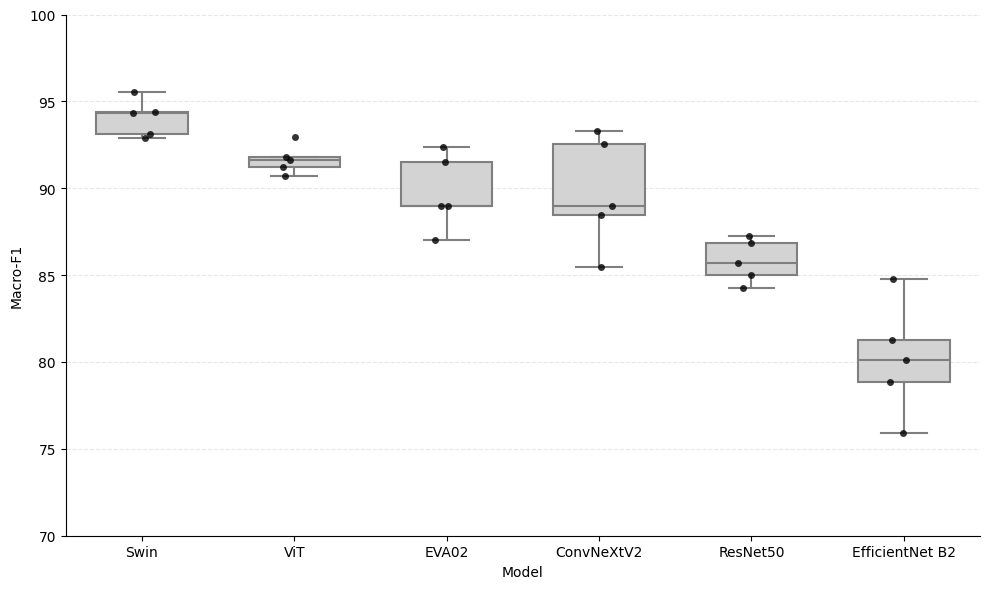

In [ ]:
# -----------------------
# BOXPLOT — Macro-F1/model/seed)
# -----------------------

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# simplify model names
# -----------------------
name_map = {
    "timm/swin_tiny_patch4_window7_224.ms_in22k_ft_in1k": "Swin",
    "timm/vit_tiny_patch16_384.augreg_in21k_ft_in1k": "ViT",
    "timm/resnet50.a1_in1k": "ResNet50",
    "timm/convnextv2_tiny.fcmae_ft_in22k_in1k_384": "ConvNeXtV2",
    "timm/tf_efficientnetv2_s.in21k_ft_in1k": "EfficientNet B2",
    "timm/eva02_tiny_patch14_336.mim_in22k_ft_in1k": "EVA02"
}

plot_df = df.copy()
plot_df["model_short"] = plot_df["model_id"].map(name_map)

# order by performance
order = (
    plot_df.groupby("model_short")["val_mf1"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="model_short",
    y="val_mf1",
    order=order,
    color="lightgray",
    width=0.6,
    fliersize=0,
    linewidth=1.5
)

sns.stripplot(
    data=plot_df,
    x="model_short",
    y="val_mf1",
    order=order,
    color="black",
    size=5,
    jitter=True,
    alpha=0.8
)

plt.ylabel("Macro-F1")
plt.ylim(70, 100)
plt.xlabel("Model")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_facecolor("white")

sns.despine()

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/TCC/models/closedset_512_nocp/closed_set_macroF1.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/content/drive/MyDrive/TCC/models/closedset_512_nocp/closed_set_macroF1.png", dpi=300, bbox_inches="tight")

plt.show()

### OPENMAX + OPENPCR

Calibrate both methods

In [ ]:
# ============================================================
# ONE-CELL OPEN-SET (UNIFIED) — OpenPCS (PCA-Qmin) + OpenMax (EVT K+1)
# - Fit/calibrate only on TRAIN + VAL_CAL (no threshold leak)
# - Evaluate on VAL_TEST (disjoint) + UNKNOWN
# - VAL split is STRATIFIED by class
# - Outputs: df (per run x method) + agg (mean±std per model/method)
# - NEW: OSCR_AUC (threshold-free) computed on (VAL_TEST vs UNKNOWN)
# ============================================================

import os, random
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

from glob import glob
from tqdm import tqdm

from scipy.stats import weibull_min
from scipy.special import softmax
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score

# -----------------------
# PATHS (edite)
# -----------------------
SAVE_DIR    = "/content/drive/MyDrive/outputs/closedset"
CKPT_ROOT   = SAVE_DIR
TRAIN_DIR   = "/content/drive/MyDrive/data/patches/split_data/known/train"
VAL_DIR     = "/content/drive/MyDrive/data/patches/split_data/known/val"
UNKNOWN_DIR = "/content/drive/MyDrive/data/patches/split_data/unknown"

# -----------------------
# CONFIG (geral)
# -----------------------
BATCH_SIZE  = 16
NUM_WORKERS = 2
USE_AMP = True
IMG_SIZE_DEFAULT = 512

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Split estratificado do VAL
VAL_CAL_FRAC = 0.4

# Ponto operacional (TPR de known) p/ calibrar thresholds (opcional p/ report FPR@TPR)
TPR_KNOWN = 0.80

# -----------------------
# OpenPCS (PCA-Qmin)
# -----------------------
PCA_MAX_COMP = 16
PCA_MIN_SAMPLES = 10
PCS_FILTER_TO_CORRECT = False

# -----------------------
# OpenMax (EVT K+1)
# -----------------------
OPENMAX_ALPHA = 10
TAIL_FRAC = 0.10
TAIL_MIN  = 20
TAIL_MAX  = 200
WEIBULL_FIX_LOC0 = True
OPENMAX_FILTER_TO_CORRECT = True

# -----------------------
# OUTPUT
# -----------------------
OUT_DIR = "/content/drive/MyDrive/outputs/openset"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CURVES_DIR = os.path.join(OUT_DIR, "curves_npz")
os.makedirs(CURVES_DIR, exist_ok=True)

# -----------------------
# reproducibility
# -----------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws)
    random.seed(ws)

# -----------------------
# transforms
# -----------------------
def make_transform(_img_size: int):
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

# -----------------------
# split estratificado
# -----------------------
def split_indices_stratified(targets, seed, frac_cal):
    targets = np.asarray(targets)
    n = len(targets)
    n_cal = int(round(frac_cal * n))
    n_test = n - n_cal
    if n_cal <= 0 or n_test <= 0:
        raise ValueError(f"Split inválido: n={n}, frac_cal={frac_cal} -> n_cal={n_cal}, n_test={n_test}")

    sss = StratifiedShuffleSplit(n_splits=1, test_size=n_test, random_state=seed)
    idx = np.arange(n)
    cal_idx, test_idx = next(sss.split(idx, targets))
    return cal_idx, test_idx

def bincount_targets(ds, K):
    idx = ds.indices if isinstance(ds, Subset) else np.arange(len(ds))
    t = np.asarray(ds.dataset.targets)[idx]
    return np.bincount(t, minlength=K)

# -----------------------
# model factory (timm + img_size fallback)
# -----------------------
def create_model_safe(model_name: str, num_classes: int, img_size: int):
    import timm
    try:
        model = timm.create_model(model_name, pretrained=True, num_classes=num_classes, img_size=img_size)
    except TypeError:
        model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model

@torch.no_grad()
def forward_prelogits_and_logits(model, x):
    if hasattr(model, "forward_features") and hasattr(model, "forward_head"):
        feats = model.forward_features(x)
        emb = model.forward_head(feats, pre_logits=True)
        logits = model(x)
        if emb.ndim > 2:
            emb = emb.flatten(1)
        return emb, logits

    if hasattr(model, "avgpool"):
        holder = {}
        def hook_fn(m, inp, out):
            holder["emb"] = out.flatten(1)
        h = model.avgpool.register_forward_hook(hook_fn)
        logits = model(x)
        h.remove()
        return holder["emb"], logits

    raise ValueError("Sem caminho de embedding para esse modelo.")

@torch.no_grad()
def extract_emb_logits_labels(model, loader, desc):
    model.eval()
    embs, logits, labels = [], [], []
    for imgs, lbls in tqdm(loader, desc=desc):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(USE_AMP and device.type=="cuda")):
            emb, logit = forward_prelogits_and_logits(model, imgs)
        embs.append(emb.detach().cpu().numpy())
        logits.append(logit.detach().cpu().numpy())
        labels.append(lbls.numpy())
    return np.concatenate(embs), np.concatenate(logits), np.concatenate(labels)

# -----------------------
# metrics
# -----------------------
def eval_open_set(y_true, y_pred, K):
    labels_full = np.arange(K+1)
    macro_f1 = float(f1_score(y_true, y_pred, labels=labels_full, average="macro", zero_division=0))
    f1_unk   = float(f1_score(y_true, y_pred, labels=[K], average=None, zero_division=0)[0])
    kappa    = float(cohen_kappa_score(y_true, y_pred, labels=labels_full))
    return macro_f1, f1_unk, kappa

def auroc_ood(scores_known, scores_unk):
    # threshold-free
    y = np.concatenate([np.zeros(len(scores_known)), np.ones(len(scores_unk))])
    s = np.concatenate([scores_known, scores_unk])
    return float(roc_auc_score(y, s))

def fpr_at_tpr_known(scores_known, scores_unk, tpr_known=0.80):
    thr = float(np.quantile(np.asarray(scores_known, dtype=np.float64), tpr_known))
    fpr = float(np.mean(np.asarray(scores_unk, dtype=np.float64) <= thr))  # unknown aceito como known
    return fpr, thr

def oscr_curve_and_auc(scores_known, scores_unk, y_known, pred_known, n_points=800):
    """
    OSCR (Dhamija et al.) curve: CCR vs FPR sweeping threshold on OOD score.
    Convention:
      - accept as known if score <= thr
      - CCR = P(accepted & correct | known)  (normalized by total known)
      - FPR = P(accepted | unknown)
    Returns:
      fpr_sorted, ccr_sorted, oscr_auc
    """
    sk = np.asarray(scores_known, dtype=np.float64)
    su = np.asarray(scores_unk, dtype=np.float64)
    yk = np.asarray(y_known, dtype=int)
    pk = np.asarray(pred_known, dtype=int)
    correct = (pk == yk)

    lo = float(min(sk.min(), su.min()))
    hi = float(max(sk.max(), su.max()))
    thr_grid = np.linspace(lo, hi, n_points)

    fprs = np.empty(n_points, dtype=np.float64)
    ccrs = np.empty(n_points, dtype=np.float64)

    for i, thr in enumerate(thr_grid):
        acc_k = (sk <= thr)
        acc_u = (su <= thr)
        ccrs[i] = np.mean(acc_k & correct)  # / total known
        fprs[i] = np.mean(acc_u)            # / total unknown

    order = np.argsort(fprs)
    fpr_s = fprs[order]
    ccr_s = ccrs[order]

    # remove repeats in fpr to make trapezoid stable
    fpr_u, idx = np.unique(fpr_s, return_index=True)
    ccr_u = ccr_s[idx]

    oscr_auc = float(np.trapz(ccr_u, fpr_u))
    return fpr_u, ccr_u, oscr_auc

# ============================================================
# OpenPCS (PCA-Qmin)
# ============================================================
def fit_pca_per_class(train_emb, train_logits, train_y, K, max_comp=64, min_samples=10, filter_to_correct=False):
    pred = np.argmax(train_logits, axis=1)
    if filter_to_correct:
        keep = pred == train_y
        train_emb = train_emb[keep]
        train_y   = train_y[keep]

    D = train_emb.shape[1]
    models = {}
    global_mu = train_emb.mean(axis=0) if train_emb.shape[0] else np.zeros((D,), dtype=np.float64)

    for c in range(K):
        Xc = train_emb[train_y == c]
        if Xc.shape[0] < min_samples:
            mu = Xc.mean(axis=0) if Xc.shape[0] > 0 else global_mu
            models[c] = {"mu": mu.astype(np.float32), "U": np.zeros((D, 0), dtype=np.float32)}
            continue

        mu = Xc.mean(axis=0)
        X = (Xc - mu).astype(np.float64)

        try:
            _, _, Vt = np.linalg.svd(X, full_matrices=False)
        except np.linalg.LinAlgError:
            models[c] = {"mu": mu.astype(np.float32), "U": np.zeros((D, 0), dtype=np.float32)}
            continue

        r = min(max_comp, Vt.shape[0])
        U = Vt[:r].T.astype(np.float32)
        models[c] = {"mu": mu.astype(np.float32), "U": U}

    return models

def score_Qmin(emb, pca_models, K):
    Xall = emb.astype(np.float64)
    N, D = Xall.shape
    Qmin = np.full((N,), np.inf, dtype=np.float64)

    for c in range(K):
        mu = pca_models[c]["mu"].astype(np.float64)
        U  = pca_models[c]["U"].astype(np.float64)

        X = Xall - mu[None, :]
        if U.shape[1] == 0:
            q = np.sum(X * X, axis=1)
        else:
            Z = X @ U
            Xhat = Z @ U.T
            R = X - Xhat
            q = np.sum(R * R, axis=1)

        Qmin = np.minimum(Qmin, q)

    return Qmin

def calibrate_threshold_on_known(scores_known, tpr_known=0.95):
    s = np.asarray(scores_known, dtype=np.float64)
    return float(np.quantile(s, tpr_known))

# ============================================================
# OpenMax (EVT K+1)
# ============================================================
def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def cosine_dist(emb_n, centroid_n):
    return 1.0 - np.clip(emb_n @ centroid_n, -1.0, 1.0)

def fit_weibull_tail(dists, tail_frac=0.10, tail_min=20, tail_max=200, fix_loc0=True):
    d = np.asarray(dists, dtype=np.float64)
    d = d[np.isfinite(d)]
    if d.size < tail_min:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

    d_sorted = np.sort(d)
    tail_n = int(np.ceil(d_sorted.size * tail_frac))
    tail_n = max(tail_min, min(tail_n, tail_max, d_sorted.size))
    tail = d_sorted[-tail_n:]
    tail = np.maximum(tail, 1e-8)

    try:
        if fix_loc0:
            shape, loc, scale = weibull_min.fit(tail, floc=0.0)
        else:
            shape, loc, scale = weibull_min.fit(tail)
        scale = max(scale, 1e-8)
        return np.array([shape, loc, scale], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

def openmax_calibrate(train_emb, train_logits, train_y, K, filter_to_correct=True):
    pred = np.argmax(train_logits, axis=1)
    if filter_to_correct:
        keep = pred == train_y
        train_emb = train_emb[keep]
        train_y   = train_y[keep]

    emb_n = l2_normalize(train_emb)
    D = emb_n.shape[1]

    mav = np.zeros((K, D), dtype=np.float32)
    weib = np.full((K, 3), np.nan, dtype=np.float64)

    global_mu = emb_n.mean(axis=0) if emb_n.shape[0] else np.zeros((D,), dtype=np.float64)
    global_mu = global_mu / (np.linalg.norm(global_mu) + 1e-12)

    for c in range(K):
        idx = np.where(train_y == c)[0]
        if idx.size == 0:
            mav[c] = global_mu.astype(np.float32)
            continue

        mu = emb_n[idx].mean(axis=0)
        mu = mu / (np.linalg.norm(mu) + 1e-12)
        mav[c] = mu.astype(np.float32)

        dists = cosine_dist(emb_n[idx], mu)
        weib[c] = fit_weibull_tail(
            dists, tail_frac=TAIL_FRAC, tail_min=TAIL_MIN, tail_max=TAIL_MAX, fix_loc0=WEIBULL_FIX_LOC0
        )

    return mav.astype(np.float32), weib.astype(np.float64)

def openmax_probs_kplus1(emb, logits, mav_n, weib_params, alpha=10):
    emb_n = l2_normalize(emb)
    z = np.asarray(logits, dtype=np.float64)
    N, K = z.shape
    a = min(alpha, K)

    omega = np.array([(a - r) / a for r in range(a)], dtype=np.float64)
    probs = np.zeros((N, K + 1), dtype=np.float64)

    mav_n = np.asarray(mav_n, dtype=np.float64)
    mav_n = mav_n / (np.linalg.norm(mav_n, axis=1, keepdims=True) + 1e-12)

    for i in range(N):
        zi = np.clip(z[i], -50, 50)
        ranks = np.argsort(zi)[::-1][:a]

        zi_adj = zi.copy()
        unk_logit = 0.0

        for rpos, k in enumerate(ranks):
            params = weib_params[k]
            if np.any(np.isnan(params)):
                continue

            d = float(1.0 - np.dot(emb_n[i], mav_n[k]))
            shape, loc, scale = float(params[0]), float(params[1]), float(params[2])
            w = float(weibull_min.cdf(d, shape, loc=loc, scale=max(scale, 1e-6)))
            w = float(np.clip(w, 0.0, 1.0))

            base = max(zi[k], 0.0)
            delta = base * (omega[rpos] * w)

            zi_adj[k] = zi_adj[k] - delta
            unk_logit += delta

        z_k1 = np.concatenate([zi_adj, np.array([unk_logit], dtype=np.float64)])
        probs[i] = softmax(z_k1)

    return probs

# -----------------------
# classes fixas
# -----------------------
base_train = ImageFolder(TRAIN_DIR, transform=transforms.ToTensor())
class_names = base_train.classes
K = len(class_names)
print(f"Known classes ({K}): {class_names}")

# -----------------------
# scan runs
# -----------------------
ckpts = sorted(glob(os.path.join(CKPT_ROOT, "**", "best_model.pt"), recursive=True))
print(f"\nRuns encontrados: {len(ckpts)}")
if len(ckpts) == 0:
    raise FileNotFoundError("Não achei best_model.pt. Verifique CKPT_ROOT/SAVE_DIR.")

results = []

for ckpt_path in ckpts:
    run_dir    = os.path.dirname(ckpt_path)
    seed_dir   = os.path.basename(run_dir)
    model_name = os.path.basename(os.path.dirname(run_dir))

    try:
        seed = int(seed_dir.split("_")[-1])
    except:
        seed = 0

    set_seed(seed)
    tfm = make_transform(IMG_SIZE_DEFAULT)

    train_ds = ImageFolder(TRAIN_DIR, transform=tfm)
    val_full = ImageFolder(VAL_DIR, transform=tfm)
    unk_ds   = ImageFolder(UNKNOWN_DIR, transform=tfm)

    assert train_ds.classes == class_names, "Class mapping mudou no TRAIN!"
    assert val_full.classes == class_names, "Class mapping mudou no VAL!"

    cal_idx, test_idx = split_indices_stratified(val_full.targets, seed, VAL_CAL_FRAC)
    val_cal_ds  = Subset(val_full, cal_idx)
    val_test_ds = Subset(val_full, test_idx)

    print(f"\n[RUN] {model_name}/{seed_dir} | img={IMG_SIZE_DEFAULT} | VAL_CAL_FRAC={VAL_CAL_FRAC} | TPR_KNOWN={TPR_KNOWN}")
    print(f"VAL sizes: full={len(val_full)} | cal={len(val_cal_ds)} | test={len(val_test_ds)}")
    cal_counts  = bincount_targets(val_cal_ds, K)
    test_counts = bincount_targets(val_test_ds, K)
    print("VAL_CAL counts :", dict(zip(class_names, cal_counts.tolist())))
    print("VAL_TEST counts:", dict(zip(class_names, test_counts.tolist())))

    g = torch.Generator().manual_seed(seed)
    loader_args = dict(
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=True
    )

    train_loader   = DataLoader(train_ds,     batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)
    val_cal_loader = DataLoader(val_cal_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)
    val_tst_loader = DataLoader(val_test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)
    unk_loader     = DataLoader(unk_ds,      batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)

    model = create_model_safe(model_name, K, IMG_SIZE_DEFAULT).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state, strict=True)
    model.eval()

    embT, logT, yT = extract_emb_logits_labels(model, train_loader,   "Train (calib)")
    embC, logC, yC = extract_emb_logits_labels(model, val_cal_loader, "VAL-CAL")
    embK, logK, yK = extract_emb_logits_labels(model, val_tst_loader, "VAL-TEST")
    embU, logU, _  = extract_emb_logits_labels(model, unk_loader,     "Unknown")

    # ============================================================
    # METHOD 1) OpenPCS
    # ============================================================
    pca_models = fit_pca_per_class(
        embT, logT, yT, K,
        max_comp=PCA_MAX_COMP, min_samples=PCA_MIN_SAMPLES,
        filter_to_correct=PCS_FILTER_TO_CORRECT
    )

    sC = score_Qmin(embC, pca_models, K)
    sK = score_Qmin(embK, pca_models, K)
    sU = score_Qmin(embU, pca_models, K)

    predC = np.argmax(logC, axis=1)
    sC_cal = sC[predC == yC] if PCS_FILTER_TO_CORRECT else sC

    mu = float(np.mean(sC_cal))
    std = float(np.std(sC_cal) + 1e-8)
    std = max(std, 1e-6)

    def norm_z(x):
        x = np.asarray(x, dtype=np.float64)
        return (x - mu) / std

    sC_n = norm_z(sC_cal)
    sK_n = norm_z(sK)
    sU_n = norm_z(sU)

    thr_pcs_z = calibrate_threshold_on_known(sC_n, tpr_known=TPR_KNOWN)

    predK_closed = np.argmax(logK, axis=1).astype(int)
    predU_closed = np.argmax(logU, axis=1).astype(int)

    predK_pcs = np.where(sK_n <= thr_pcs_z, predK_closed, K).astype(int)
    predU_pcs = np.where(sU_n <= thr_pcs_z, predU_closed, K).astype(int)

    y_true = np.concatenate([yK.astype(int), np.full(len(predU_pcs), K, dtype=int)])
    y_pred = np.concatenate([predK_pcs, predU_pcs])

    macro_f1, f1_unk, kappa = eval_open_set(y_true, y_pred, K)

    # threshold-free
    auroc = auroc_ood(sK_n, sU_n)
    _, _, oscr_auc = oscr_curve_and_auc(sK_n, sU_n, yK, predK_closed)

    thr_fpr = float(np.quantile(sC_n, TPR_KNOWN))
    fpr = float(np.mean(sU_n <= thr_fpr))
    TPR_valtest = float(np.mean(sK_n <= thr_fpr))

    results.append({
        "model_name": model_name,
        "seed": seed,
        "method": "OpenPCS-Qmin (VALsplit)",
        "TPR_known": float(TPR_KNOWN),
        "VAL_CAL_FRAC": float(VAL_CAL_FRAC),

        "FPR@TPR": float(fpr),
        "thr@TPR": float(thr_fpr),
        "TPR_valtest": float(TPR_valtest),
        "thr_method": float(thr_pcs_z),

        "AUROC": float(auroc),
        "OSCR_AUC": float(oscr_auc),

        "macro_f1": float(macro_f1),
        "f1_unknown": float(f1_unk),
        "kappa": float(kappa),
    })

    np.savez_compressed(
        os.path.join(CURVES_DIR, f"{model_name}__seed{seed}__OpenPCS.npz"),
        method="OpenPCS",
        model_name=model_name,
        seed=int(seed),
        scores_known=sK_n.astype(np.float32),
        scores_unk=sU_n.astype(np.float32),
        y_known=yK.astype(np.int16),
        pred_known=predK_closed.astype(np.int16),
        thr_method=float(thr_pcs_z),
    )

    # ============================================================
    # METHOD 2) OpenMax
    # ============================================================
    mav, weib = openmax_calibrate(
        embT, logT, yT, K,
        filter_to_correct=OPENMAX_FILTER_TO_CORRECT
    )

    probsC = openmax_probs_kplus1(embC, logC, mav, weib, alpha=OPENMAX_ALPHA)
    probsK = openmax_probs_kplus1(embK, logK, mav, weib, alpha=OPENMAX_ALPHA)
    probsU = openmax_probs_kplus1(embU, logU, mav, weib, alpha=OPENMAX_ALPHA)

    sC_om = probsC[:, K]
    sK_om = probsK[:, K]
    sU_om = probsU[:, K]

    thr_om = float(np.quantile(np.asarray(sC_om, dtype=np.float64), TPR_KNOWN))

    predK_known = np.argmax(probsK[:, :K], axis=1).astype(int)
    predU_known = np.argmax(probsU[:, :K], axis=1).astype(int)

    predK_om_thr = np.where(sK_om >= thr_om, K, predK_known).astype(int)
    predU_om_thr = np.where(sU_om >= thr_om, K, predU_known).astype(int)

    y_true = np.concatenate([yK.astype(int), np.full(len(predU_om_thr), K, dtype=int)])
    y_pred = np.concatenate([predK_om_thr, predU_om_thr])

    macro_f1, f1_unk, kappa = eval_open_set(y_true, y_pred, K)

    # threshold-free
    auroc = auroc_ood(sK_om, sU_om)
    _, _, oscr_auc = oscr_curve_and_auc(sK_om, sU_om, yK, predK_known)

    fpr_om = float(np.mean(np.asarray(sU_om, dtype=np.float64) < thr_om))
    tpr_valtest_om = float(np.mean(np.asarray(sK_om, dtype=np.float64) < thr_om))

    results.append({
        "model_name": model_name,
        "seed": seed,
        "method": "OpenMax (thr on P(unk) @VAL_CAL)",

        "TPR_known": float(TPR_KNOWN),
        "VAL_CAL_FRAC": float(VAL_CAL_FRAC),

        "FPR@TPR": float(fpr_om),
        "thr@TPR": float(thr_om),
        "TPR_valtest": float(tpr_valtest_om),
        "thr_method": float(thr_om),

        "AUROC": float(auroc),
        "OSCR_AUC": float(oscr_auc),

        "macro_f1": float(macro_f1),
        "f1_unknown": float(f1_unk),
        "kappa": float(kappa),

        "OPENMAX_ALPHA": int(OPENMAX_ALPHA),
        "TAIL_FRAC": float(TAIL_FRAC),
        "TAIL_MIN": int(TAIL_MIN),
        "TAIL_MAX": int(TAIL_MAX),
        "OPENMAX_FILTER_TO_CORRECT": bool(OPENMAX_FILTER_TO_CORRECT),
    })

    np.savez_compressed(
        os.path.join(CURVES_DIR, f"{model_name}__seed{seed}__OpenMax.npz"),
        method="OpenMax",
        model_name=model_name,
        seed=int(seed),
        scores_known=np.asarray(sK_om, dtype=np.float64).astype(np.float32),
        scores_unk=np.asarray(sU_om, dtype=np.float64).astype(np.float32),
        y_known=yK.astype(np.int16),
        pred_known=predK_known.astype(np.int16),
        thr_method=float(thr_om),
    )

    del model
    torch.cuda.empty_cache()

# -----------------------
# summarize
# -----------------------
df = pd.DataFrame(results)
print("\n=== RESULTADOS (por run x método) ===")
display(df.sort_values(["model_name","seed","method"]))

agg = df.groupby(["model_name","method"]).agg(
    n=("seed","count"),

    AUROC_mean=("AUROC","mean"),
    AUROC_std=("AUROC","std"),

    OSCR_AUC_mean=("OSCR_AUC","mean"),
    OSCR_AUC_std=("OSCR_AUC","std"),

    FPR_mean=("FPR@TPR","mean"),
    FPR_std=("FPR@TPR","std"),

    macroF1_mean=("macro_f1","mean"),
    macroF1_std=("macro_f1","std"),

    f1unk_mean=("f1_unknown","mean"),
    f1unk_std=("f1_unknown","std"),

    kappa_mean=("kappa","mean"),
    kappa_std=("kappa","std"),
).reset_index()

print("\n=== AGG (média±std por modelo/método) ===")
display(agg.sort_values(["macroF1_mean","AUROC_mean"], ascending=False))

# -----------------------
# SAVE RESULTS
# -----------------------
out_runs = os.path.join(OUT_DIR, "open_set_runs_unified.csv")
out_agg  = os.path.join(OUT_DIR, "open_set_agg_unified.csv")

df.to_csv(out_runs, index=False)
agg.to_csv(out_agg, index=False)

print("\nSaved:")
print(" -", out_runs)
print(" -", out_agg)
print(" - curves:", CURVES_DIR)


### ROC / OSCR curves

Loaded: 60 runs from /content/drive/MyDrive/TCC/models/article_open_set_results_512_unified_openpcs_openmax/curves_npz
Models: ['convnextv2_tiny.fcmae_ft_in22k_in1k_384', 'eva02_tiny_patch14_336.mim_in22k_ft_in1k', 'resnet50.a1_in1k', 'swin_tiny_patch4_window7_224.ms_in22k_ft_in1k', 'tf_efficientnetv2_s.in21k_ft_in1k', 'vit_tiny_patch16_384.augreg_in21k_ft_in1k']
Methods: ['OpenMax', 'OpenPCS']


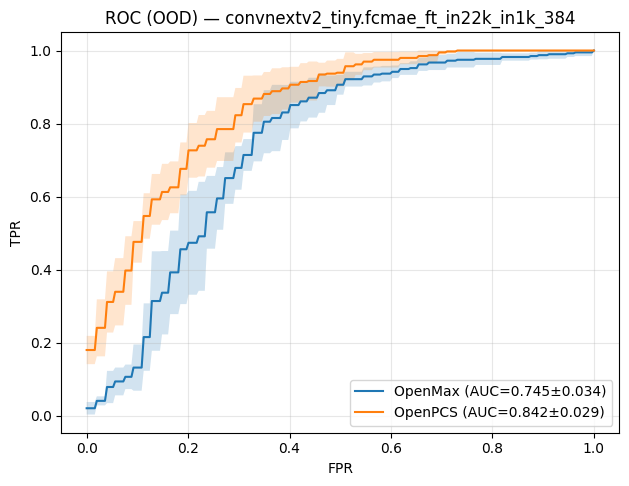

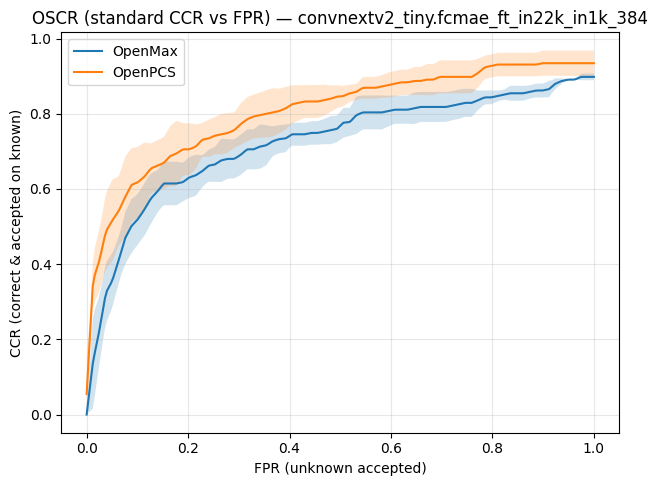

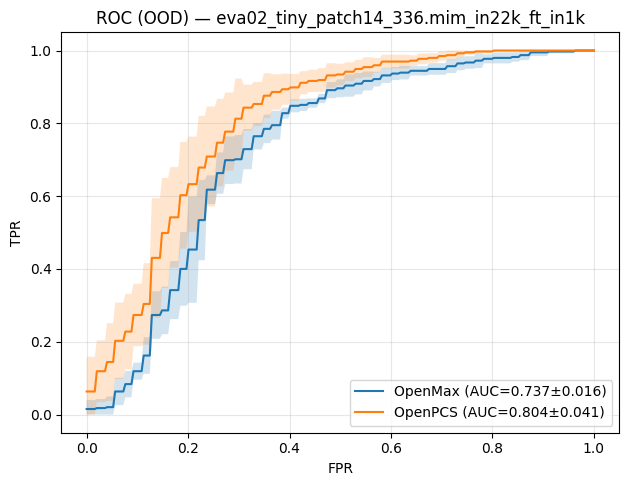

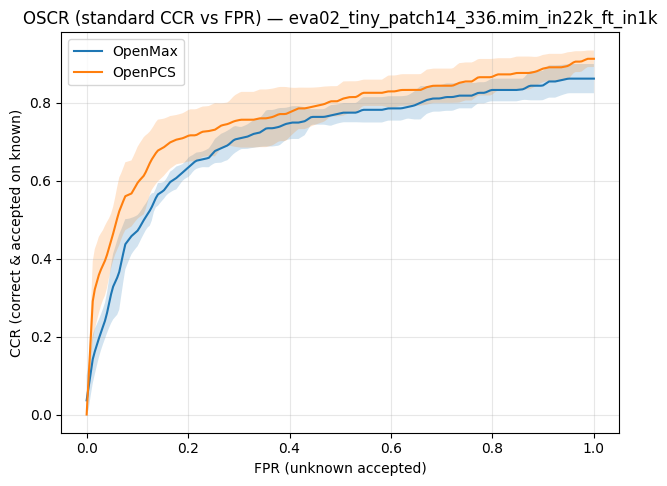

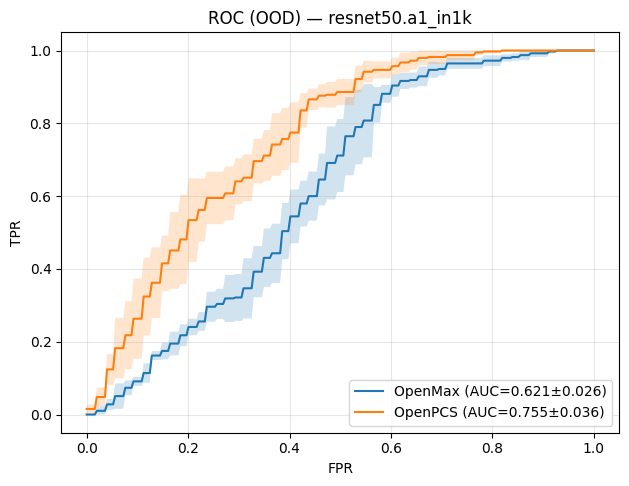

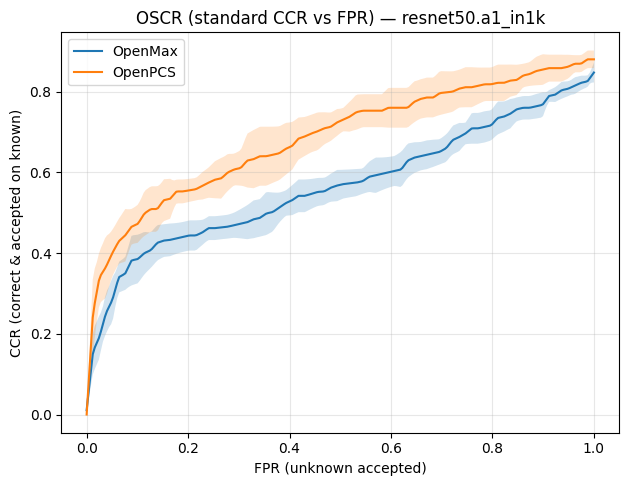

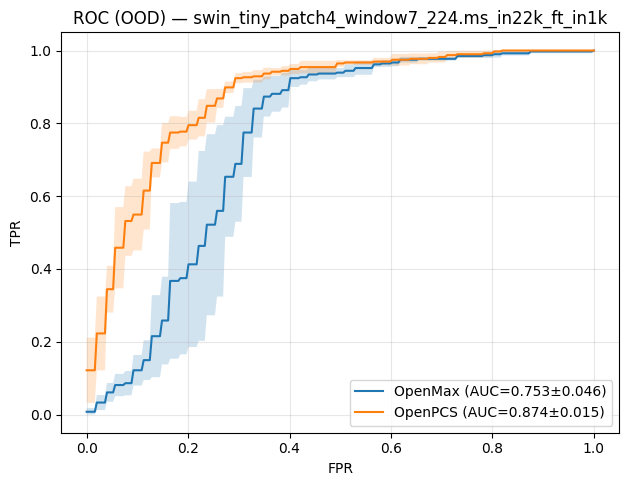

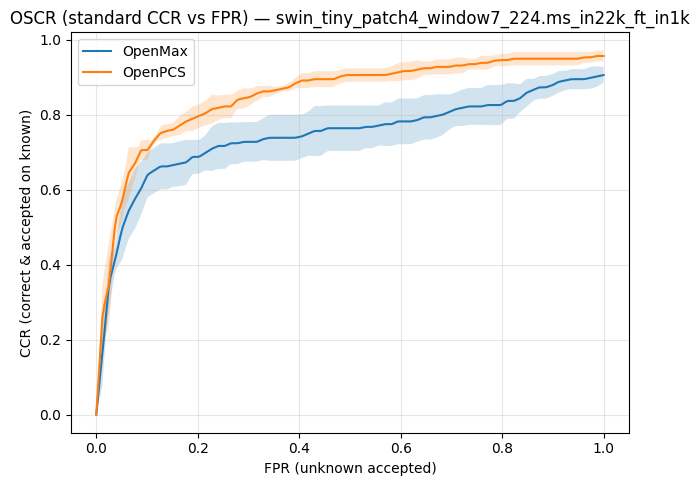

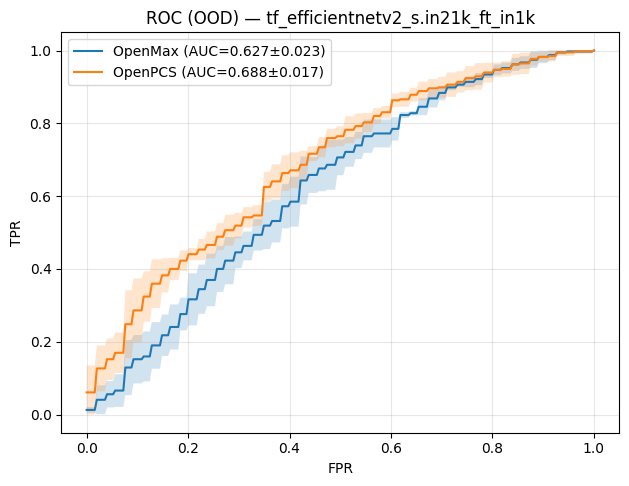

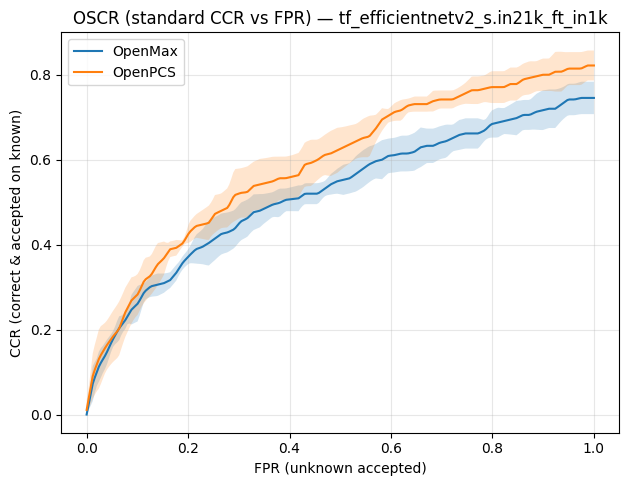

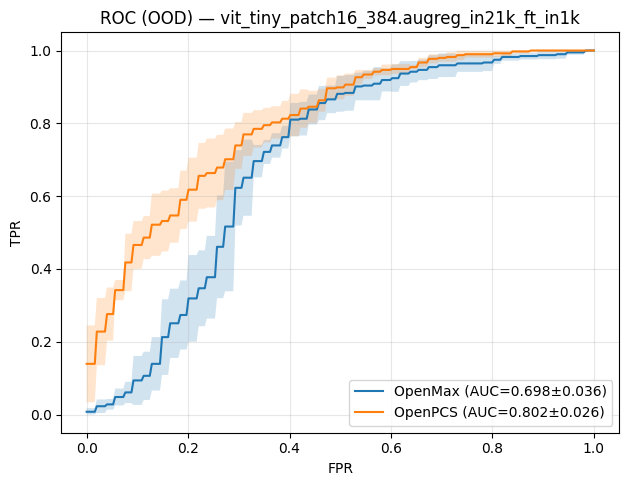

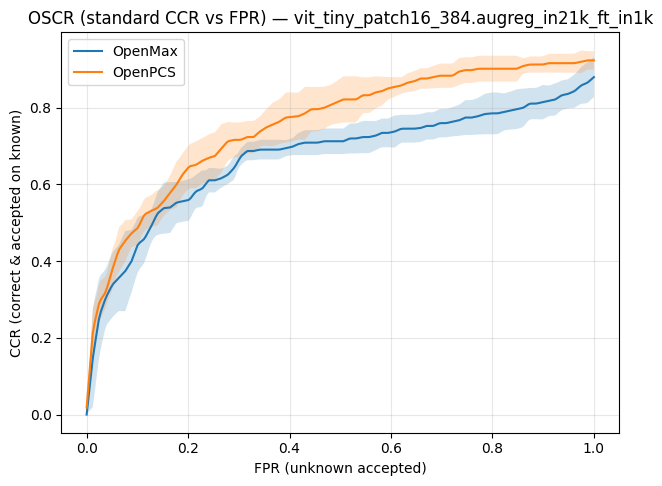

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import roc_curve, auc

CURVES_DIR = "/content/drive/MyDrive/outputs/openset/curves_npz"

# Se quiser marcar o operating point (thr_method) no OSCR, ligue:
PLOT_THR_POINT = False

# -----------------------
# Load npz
# -----------------------
def load_curves(curves_dir):
    items = []
    fps = sorted(glob(os.path.join(curves_dir, "*.npz")))
    for fp in fps:
        d = np.load(fp, allow_pickle=True)

        required = ["method","model_name","seed","scores_known","scores_unk","y_known","pred_known"]
        missing = [k for k in required if k not in d.files]
        if missing:
            print(f"[SKIP] {os.path.basename(fp)} missing keys: {missing}")
            continue

        thr = float(d["thr_method"]) if "thr_method" in d.files else np.nan

        items.append({
            "file": os.path.basename(fp),
            "method": str(d["method"]),
            "model_name": str(d["model_name"]),
            "seed": int(d["seed"]),
            "scores_known": np.asarray(d["scores_known"], dtype=np.float64),
            "scores_unk":   np.asarray(d["scores_unk"], dtype=np.float64),
            "y_known":      np.asarray(d["y_known"], dtype=int),
            "pred_known":   np.asarray(d["pred_known"], dtype=int),
            "thr_method":   thr,
        })
    return items

items = load_curves(CURVES_DIR)
print("Loaded:", len(items), "runs from", CURVES_DIR)

if len(items) == 0:
    print("=> Nenhum .npz encontrado (ou todos foram pulados por chaves faltando).")
    # não dá pra plotar sem curvas
    raise SystemExit

# -----------------------
# Mean ROC (OOD) (interpolated)
# -----------------------
def mean_roc(curve_list, n_points=250):
    mean_fpr = np.linspace(0.0, 1.0, n_points)
    tprs = []
    aucs = []

    for c in curve_list:
        y = np.concatenate([np.zeros(len(c["scores_known"])), np.ones(len(c["scores_unk"]))])
        s = np.concatenate([c["scores_known"], c["scores_unk"]])

        fpr, tpr, _ = roc_curve(y, s)  # positive = unknown
        tpr_i = np.interp(mean_fpr, fpr, tpr)
        tprs.append(tpr_i)
        aucs.append(auc(fpr, tpr))

    tprs = np.asarray(tprs)
    return mean_fpr, tprs.mean(0), tprs.std(0), float(np.mean(aucs)), float(np.std(aucs))

# -----------------------
# OSCR (standard CCR vs FPR)
# score maior => mais unknown
# accept-as-known se score < thr
# CCR = P(accepted AND correct) sobre TODOS os known
# FPR = P(accepted) sobre unknown
# -----------------------
def oscr_curve(scores_known, scores_unk, y_known, pred_known, n_points=800):
    sk = np.asarray(scores_known, dtype=np.float64)
    su = np.asarray(scores_unk, dtype=np.float64)
    yk = np.asarray(y_known, dtype=int)
    pk = np.asarray(pred_known, dtype=int)

    correct = (pk == yk)

    # thresholds pela união (padrão)
    all_s = np.concatenate([sk, su])
    thr_grid = np.linspace(all_s.min(), all_s.max(), n_points)

    fprs = np.empty(n_points, dtype=np.float64)
    ccrs = np.empty(n_points, dtype=np.float64)

    for i, thr in enumerate(thr_grid):
        acc_k = (sk < thr)          # known accepted
        acc_u = (su < thr)          # unknown accepted
        ccrs[i] = float(np.mean(acc_k & correct))
        fprs[i] = float(np.mean(acc_u))

    # ordenar por FPR crescente e remover duplicatas (estabiliza interp)
    order = np.argsort(fprs)
    fpr = fprs[order]
    ccr = ccrs[order]
    fpr_u, idx = np.unique(fpr, return_index=True)
    ccr_u = ccr[idx]
    return fpr_u, ccr_u

def mean_oscr(curve_list, n_points=250):
    mean_fpr = np.linspace(0.0, 1.0, n_points)
    ccrs = []

    for c in curve_list:
        fpr, ccr = oscr_curve(
            c["scores_known"], c["scores_unk"], c["y_known"], c["pred_known"],
            n_points=1000
        )
        ccr_i = np.interp(mean_fpr, fpr, ccr, left=ccr[0], right=ccr[-1])
        ccrs.append(ccr_i)

    ccrs = np.asarray(ccrs)
    return mean_fpr, ccrs.mean(0), ccrs.std(0)

def oscr_point(scores_known, scores_unk, y_known, pred_known, thr):
    sk = np.asarray(scores_known, dtype=np.float64)
    su = np.asarray(scores_unk, dtype=np.float64)
    yk = np.asarray(y_known, dtype=int)
    pk = np.asarray(pred_known, dtype=int)
    correct = (pk == yk)
    acc_k = (sk < thr)
    acc_u = (su < thr)
    return float(np.mean(acc_u)), float(np.mean(acc_k & correct))  # (FPR, CCR)

# -----------------------
# Plot per model_name
# -----------------------
models  = sorted(set(x["model_name"] for x in items))
methods = sorted(set(x["method"] for x in items))
print("Models:", models)
print("Methods:", methods)

for model in models:
    # ROC
    plt.figure(figsize=(7.2, 5.2))
    for m in methods:
        curves = [x for x in items if x["model_name"] == model and x["method"] == m]
        if not curves:
            continue

        fpr, tpr_mean, tpr_std, auc_mean, auc_std = mean_roc(curves)
        plt.plot(fpr, tpr_mean, label=f"{m} (AUC={auc_mean:.3f}±{auc_std:.3f})")
        plt.fill_between(
            fpr,
            np.clip(tpr_mean - tpr_std, 0, 1),
            np.clip(tpr_mean + tpr_std, 0, 1),
            alpha=0.2
        )

    plt.title(f"ROC (OOD) — {model}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # OSCR
    plt.figure(figsize=(7.2, 5.2))
    for m in methods:
        curves = [x for x in items if x["model_name"] == model and x["method"] == m]
        if not curves:
            continue

        fpr, ccr_mean, ccr_std = mean_oscr(curves)
        plt.plot(fpr, ccr_mean, label=f"{m}")
        plt.fill_between(
            fpr,
            np.clip(ccr_mean - ccr_std, 0, 1),
            np.clip(ccr_mean + ccr_std, 0, 1),
            alpha=0.2
        )

        if PLOT_THR_POINT:
            thr_vals = [c["thr_method"] for c in curves if np.isfinite(c["thr_method"])]
            if len(thr_vals) > 0:
                thr_bar = float(np.mean(thr_vals))
                pts = [oscr_point(c["scores_known"], c["scores_unk"], c["y_known"], c["pred_known"], thr_bar)
                       for c in curves]
                fpr_pt = float(np.mean([p[0] for p in pts]))
                ccr_pt = float(np.mean([p[1] for p in pts]))
                plt.scatter([fpr_pt], [ccr_pt], s=40, marker="o", label=f"{m} @thr")

    plt.title(f"OSCR (standard CCR vs FPR) — {model}")
    plt.xlabel("FPR (unknown accepted)")
    plt.ylabel("CCR (correct & accepted on known)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## Confusion Matrix

Device: cuda

Using: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k | OpenPCR-Qmin | seed: 1

Forward...


Unknown: 100%|██████████| 5/5 [00:02<00:00,  1.68it/s]


[OpenPCR] thr (quantile@TPR=0.8) = 44.2961

=== SUMMARY (K+1) ===
Model: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k | Method: OpenPCR-Qmin | seed: 1 | img: 512
Accuracy:           0.8059
Balanced accuracy:  0.7742
Macro F1:           0.7988
Weighted F1:        0.8003
Cohen's kappa:      0.7251

=== CLASSIFICATION REPORT (K+1) ===
                        precision    recall  f1-score   support

   Byrsonima laxiflora     0.8182    0.6923    0.7500        13
Copaifera langsdorffii     0.7955    0.9722    0.8750        36
  Maprounea guianensis     0.7143    0.5556    0.6250         9
      Ocotea corymbosa     0.8750    0.5385    0.6667        13
   Persea willdernovii     1.0000    0.6250    0.7692         8
 Syagrus romanzoffiana     1.0000    1.0000    1.0000         7
    Symplocos revoluta     0.8333    1.0000    0.9091         5
               unknown     0.7805    0.8101    0.7950        79

              accuracy                         0.8059       170
             macro avg 

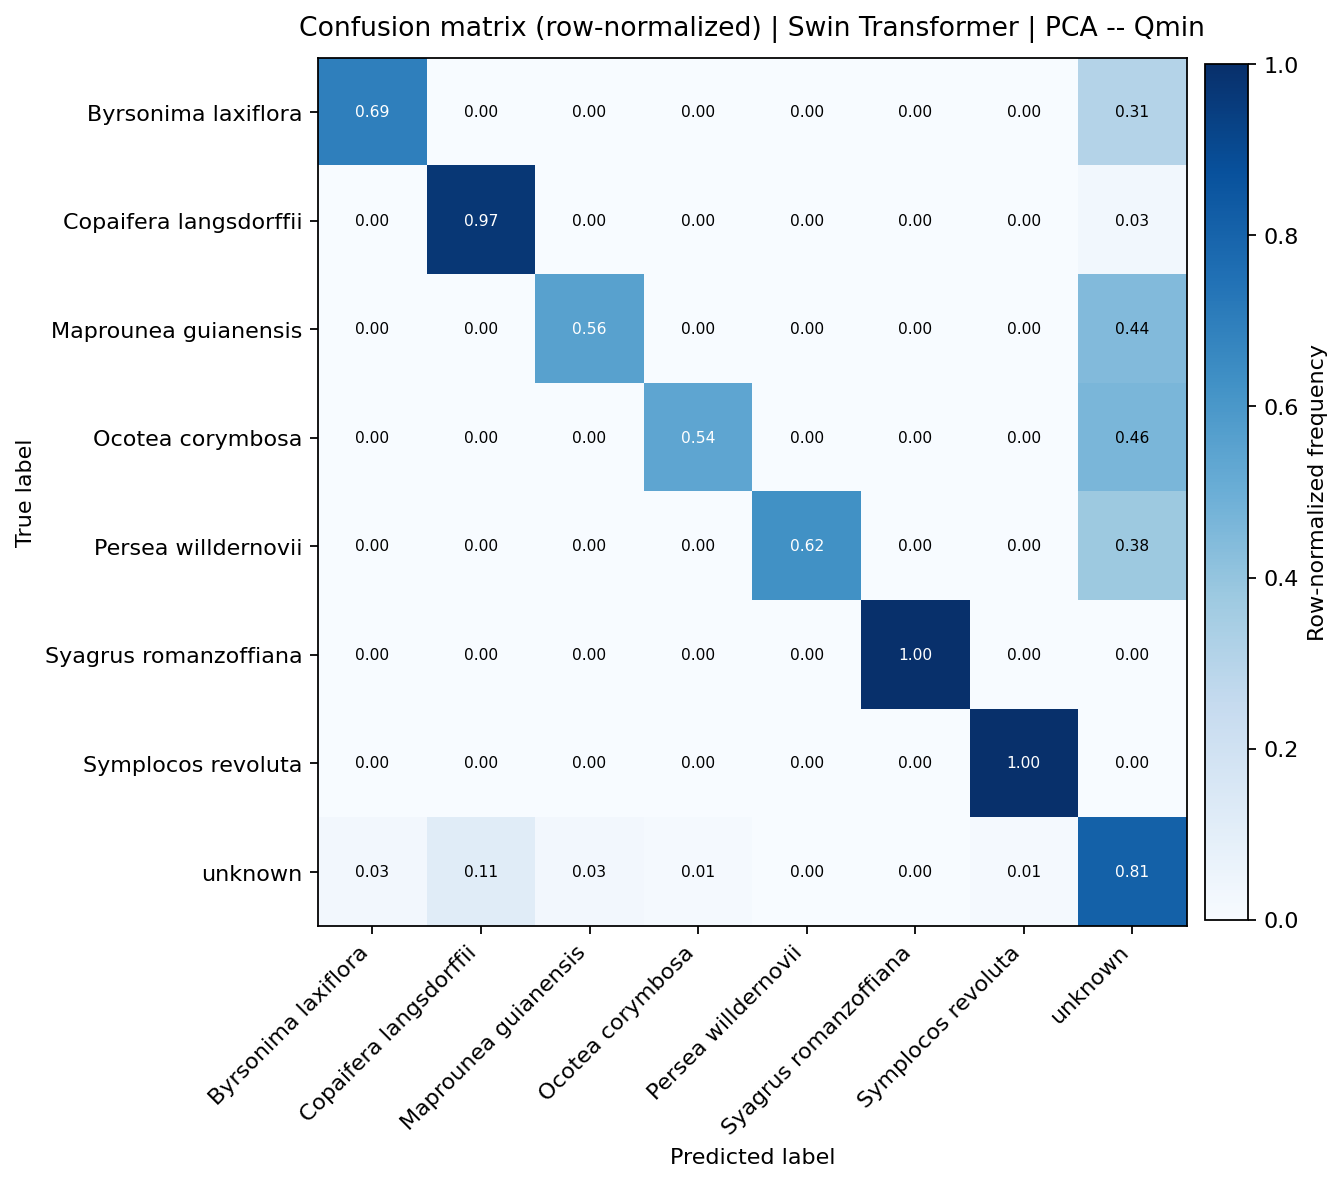

In [ ]:
import os, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

from glob import glob
from tqdm import tqdm

from scipy.stats import weibull_min
from scipy.special import softmax
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score
)

import matplotlib.pyplot as plt

# -----------------------
# PATHS (edite)
# -----------------------
SAVE_DIR    = "/content/drive/MyDrive/TCC/models/closedset_512_nocp"
TRAIN_DIR   = "/content/drive/MyDrive/TCC/patches/split_data/known/train"
VAL_DIR     = "/content/drive/MyDrive/TCC/patches/split_data/known/val"
UNKNOWN_DIR = "/content/drive/MyDrive/TCC/patches/split_data/unknown"

# onde está o agg/runs do open-set (se você salvou)
OUT_DIR = "/content/drive/MyDrive/TCC/models/cm_best_openset"
AGG_CSV = os.path.join(OUT_DIR, "open_set_agg.csv")   # ajuste se o nome for outro
RUNS_CSV = os.path.join(OUT_DIR, "open_set_runs.csv") # ajuste se o nome for outro

# -----------------------
# CONFIG
# -----------------------
BATCH_SIZE  = 16
NUM_WORKERS = 2
USE_AMP = True
IMG_SIZE_DEFAULT = 512

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Operating point (para OpenPCR threshold)
TPR_KNOWN = 0.80  # ajuste para o TPR que você está usando

# OpenMax knobs
OPENMAX_ALPHA = 10
TAIL_FRAC = 0.10
TAIL_MIN  = 20
TAIL_MAX  = 200
WEIBULL_FIX_LOC0 = True

# Se não achar o AGG_CSV, cai nesses defaults:
DEFAULT_BEST_MODEL  = "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k"
DEFAULT_BEST_METHOD = "OpenPCR-Qmin"  # ou "OpenMax-classic"
DEFAULT_SEED = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------
# reproducibility
# -----------------------
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws); random.seed(ws)

# -----------------------
# transforms
# -----------------------
def make_transform():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

# -----------------------
# model factory (timm + img_size fallback)
# -----------------------
def create_model_safe(model_name: str, num_classes: int, img_size: int):
    import timm
    try:
        model = timm.create_model(model_name, pretrained=True, num_classes=num_classes, img_size=img_size)
    except TypeError:
        model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model

@torch.no_grad()
def forward_prelogits_and_logits(model, x):
    if hasattr(model, "forward_features") and hasattr(model, "forward_head"):
        feats = model.forward_features(x)
        emb = model.forward_head(feats, pre_logits=True)
        logits = model(x)
        if emb.ndim > 2:
            emb = emb.flatten(1)
        return emb, logits
    if hasattr(model, "avgpool"):
        holder = {}
        def hook_fn(m, inp, out):
            holder["emb"] = out.flatten(1)
        h = model.avgpool.register_forward_hook(hook_fn)
        logits = model(x)
        h.remove()
        return holder["emb"], logits
    raise ValueError("Sem caminho de embedding para esse modelo.")

@torch.no_grad()
def extract_emb_logits_labels(model, loader, desc):
    model.eval()
    embs, logits, labels = [], [], []
    for imgs, lbls in tqdm(loader, desc=desc):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(USE_AMP and device.type=="cuda")):
            emb, logit = forward_prelogits_and_logits(model, imgs)
        embs.append(emb.detach().cpu().numpy())
        logits.append(logit.detach().cpu().numpy())
        labels.append(lbls.numpy())
    return np.concatenate(embs), np.concatenate(logits), np.concatenate(labels)

# -----------------------
# OpenPCR (PCA per class + Qmin)
# -----------------------
def fit_pca_per_class(train_emb, train_logits, train_y, K, max_comp=64, min_samples=10):
    # padrão do seu setup anterior: calibra com corretas
    pred = np.argmax(train_logits, axis=1)
    keep = (pred == train_y)
    train_emb = train_emb[keep]
    train_y   = train_y[keep]

    D = train_emb.shape[1]
    models = {}
    global_mu = train_emb.mean(axis=0)

    for c in range(K):
        Xc = train_emb[train_y == c]
        if Xc.shape[0] < min_samples:
            mu = Xc.mean(axis=0) if Xc.shape[0] > 0 else global_mu
            models[c] = {"mu": mu.astype(np.float32), "U": np.zeros((D, 0), dtype=np.float32)}
            continue

        mu = Xc.mean(axis=0)
        X = (Xc - mu).astype(np.float64)
        try:
            _, _, Vt = np.linalg.svd(X, full_matrices=False)
        except np.linalg.LinAlgError:
            models[c] = {"mu": mu.astype(np.float32), "U": np.zeros((D, 0), dtype=np.float32)}
            continue

        r = min(max_comp, Vt.shape[0])
        U = Vt[:r].T.astype(np.float32)  # [D, r]
        models[c] = {"mu": mu.astype(np.float32), "U": U}

    return models

def score_openpcr_Qmin(emb, pca_models, K):
    Xall = emb.astype(np.float64)
    Qmin = np.full((Xall.shape[0],), np.inf, dtype=np.float64)

    for c in range(K):
        mu = pca_models[c]["mu"].astype(np.float64)
        U  = pca_models[c]["U"].astype(np.float64)
        X = Xall - mu[None, :]

        if U.shape[1] == 0:
            q = np.sum(X*X, axis=1)
        else:
            Z = X @ U
            Xhat = Z @ U.T
            R = X - Xhat
            q = np.sum(R*R, axis=1)

        Qmin = np.minimum(Qmin, q)

    return Qmin

def calibrate_thr_quantile(scores_known, tpr_known):
    # accept if score <= thr
    return float(np.quantile(np.asarray(scores_known, dtype=np.float64), tpr_known))

# -----------------------
# OpenMax classic (K+1)
# -----------------------
def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def cosine_dist_to_centroid(emb_n, centroid_n):
    return 1.0 - np.clip(emb_n @ centroid_n, -1.0, 1.0)

def fit_weibull_tail(dists, tail_frac, tail_min, tail_max, fix_loc0):
    d = np.asarray(dists, dtype=np.float64)
    d = d[np.isfinite(d)]
    if d.size < tail_min:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
    d_sorted = np.sort(d)
    tail_n = int(np.ceil(d_sorted.size * tail_frac))
    tail_n = max(tail_min, min(tail_n, tail_max, d_sorted.size))
    tail = np.maximum(d_sorted[-tail_n:], 1e-8)
    try:
        if fix_loc0:
            shape, loc, scale = weibull_min.fit(tail, floc=0.0)
        else:
            shape, loc, scale = weibull_min.fit(tail)
        return np.array([shape, loc, max(scale, 1e-8)], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

def openmax_calibrate(train_emb, train_logits, train_y, K):
    pred = np.argmax(train_logits, axis=1)
    keep = (pred == train_y)
    train_emb = train_emb[keep]
    train_y   = train_y[keep]

    emb_n = l2_normalize(train_emb)
    D = emb_n.shape[1]

    centroids = np.zeros((K, D), dtype=np.float32)
    weibull_params = np.full((K, 3), np.nan, dtype=np.float64)

    global_centroid = emb_n.mean(axis=0)
    global_centroid = global_centroid / (np.linalg.norm(global_centroid) + 1e-12)

    for c in range(K):
        idx = np.where(train_y == c)[0]
        if idx.size == 0:
            centroids[c] = global_centroid.astype(np.float32)
            continue
        mu = emb_n[idx].mean(axis=0)
        mu = mu / (np.linalg.norm(mu) + 1e-12)
        centroids[c] = mu.astype(np.float32)

        dists = cosine_dist_to_centroid(emb_n[idx], mu)
        weibull_params[c] = fit_weibull_tail(dists, TAIL_FRAC, TAIL_MIN, TAIL_MAX, WEIBULL_FIX_LOC0)

    centroids_n = centroids.astype(np.float64)
    centroids_n = centroids_n / (np.linalg.norm(centroids_n, axis=1, keepdims=True) + 1e-12)
    return centroids_n, weibull_params

def openmax_recalibrate_probs(emb, logits, centroids_n, weibull_params, alpha=10):
    emb_n = l2_normalize(emb)
    logits = np.asarray(logits, dtype=np.float64)
    N, K = logits.shape
    a = min(alpha, K)
    omega = np.array([(a - r) / a for r in range(a)], dtype=np.float64)

    probs_k1 = np.zeros((N, K+1), dtype=np.float64)
    for i in range(N):
        z = np.clip(logits[i], -50, 50)
        p = softmax(z)
        ranks = np.argsort(p)[::-1][:a]

        z_adj = z.copy()
        unk_logit = 0.0
        for rpos, k in enumerate(ranks):
            params = weibull_params[k]
            if np.any(np.isnan(params)):
                continue
            d = float(1.0 - np.dot(emb_n[i], centroids_n[k]))
            shape, loc, scale = float(params[0]), float(params[1]), float(params[2])
            w = float(weibull_min.cdf(d, shape, loc=loc, scale=max(scale, 1e-6)))
            delta = z[k] * (omega[rpos] * w)
            z_adj[k] -= delta
            unk_logit += delta

        z_k1 = np.concatenate([z_adj, np.array([unk_logit], dtype=np.float64)])
        probs_k1[i] = softmax(z_k1)

    return probs_k1

# -----------------------
# helper: paper-ready CM plot
# -----------------------
def plot_cm_normalized(cm_counts, labels, title, save_path=None):
    cm = cm_counts.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, np.maximum(row_sums, 1.0), out=np.zeros_like(cm), where=row_sums > 0)

    fig, ax = plt.subplots(figsize=(8.5, 8.0), dpi=160)
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_title(title, pad=10)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    # clean look
    for spine in ax.spines.values():
      spine.set_visible(True)
      spine.set_linewidth(0.8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Row-normalized frequency")

    # annotate values
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            val = cm_norm[i, j]
            if np.isnan(val): val = 0.0
            txt = f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=7, color=("white" if val > 0.5 else "black"))

    fig.tight_layout()

    if save_path is not None:
      if isinstance(save_path, (list, tuple)):
        for p in save_path:
            fig.savefig(p, bbox_inches="tight")
      else:
        fig.savefig(save_path, bbox_inches="tight")

# -----------------------
# pick best (auto) or fallback
# -----------------------
best_model = DEFAULT_BEST_MODEL
best_method = DEFAULT_BEST_METHOD
best_seed = DEFAULT_SEED

if os.path.exists(AGG_CSV):
    agg = pd.read_csv(AGG_CSV)
    row = agg.sort_values("macroF1_mean", ascending=False).iloc[0]
    best_model = row["model_name"]
    best_method = row["method"]
    print("Auto-best from agg:", best_model, "|", best_method)

    if os.path.exists(RUNS_CSV):
        runs = pd.read_csv(RUNS_CSV)
        sub = runs[(runs["model_name"] == best_model) & (runs["method"] == best_method)]
        if len(sub) > 0 and "macro_f1" in sub.columns:
            best_seed = int(sub.sort_values("macro_f1", ascending=False).iloc[0]["seed"])
            print("Auto-best seed from runs:", best_seed)

print("\nUsing:", best_model, "|", best_method, "| seed:", best_seed)

# -----------------------
# load checkpoint
# -----------------------
ckpt_path = os.path.join(SAVE_DIR, best_model, f"seed_{best_seed}", "best_model.pt")
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint não encontrado: {ckpt_path}")

# classes
base_train = ImageFolder(TRAIN_DIR, transform=transforms.ToTensor())
class_names = base_train.classes
K = len(class_names)
labels_cm = class_names + ["unknown"]
labels_idx = np.arange(K+1)

# loaders
set_seed(best_seed)
tfm = make_transform()

train_ds = ImageFolder(TRAIN_DIR, transform=tfm)
val_ds   = ImageFolder(VAL_DIR, transform=tfm)
unk_ds   = ImageFolder(UNKNOWN_DIR, transform=tfm)

assert train_ds.classes == class_names, "Class mapping mudou no TRAIN!"
assert val_ds.classes   == class_names, "Class mapping mudou no VAL!"

g = torch.Generator().manual_seed(best_seed)
loader_args = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(device.type=="cuda"),
    worker_init_fn=seed_worker,
    generator=g,
    persistent_workers=False
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)
unk_loader   = DataLoader(unk_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)

# model
model = create_model_safe(best_model, K, IMG_SIZE_DEFAULT).to(device)
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state, strict=True)
model.eval()

print("\nForward...")
embT, logT, yT = extract_emb_logits_labels(model, train_loader, "Train (calib)")
embK, logK, yK = extract_emb_logits_labels(model, val_loader,   "Known-Val")
embU, logU, _  = extract_emb_logits_labels(model, unk_loader,   "Unknown")

# -----------------------
# predict K+1
# -----------------------
if best_method == "OpenPCR-Qmin":
    pca_models = fit_pca_per_class(embT, logT, yT, K, max_comp=64, min_samples=10)

    # calibrate threshold on VAL-known (robusto pra few-shot)
    sK = score_openpcr_Qmin(embK, pca_models, K)
    thr = calibrate_thr_quantile(sK, TPR_KNOWN)
    sU = score_openpcr_Qmin(embU, pca_models, K)

    predK_closed = np.argmax(logK, axis=1).astype(int)
    predU_closed = np.argmax(logU, axis=1).astype(int)

    predK = np.where(sK <= thr, predK_closed, K).astype(int)
    predU = np.where(sU <= thr, predU_closed, K).astype(int)

    print(f"[OpenPCR] thr (quantile@TPR={TPR_KNOWN}) = {thr:.6g}")

elif best_method == "OpenMax-classic":
    centroids_n, weibull_params = openmax_calibrate(embT, logT, yT, K)
    probsK = openmax_recalibrate_probs(embK, logK, centroids_n, weibull_params, alpha=OPENMAX_ALPHA)
    probsU = openmax_recalibrate_probs(embU, logU, centroids_n, weibull_params, alpha=OPENMAX_ALPHA)
    predK = np.argmax(probsK, axis=1).astype(int)
    predU = np.argmax(probsU, axis=1).astype(int)
else:
    raise ValueError(f"best_method inesperado: {best_method}")

y_true = np.concatenate([yK.astype(int), np.full(len(predU), K, dtype=int)])
y_pred = np.concatenate([predK, predU])

# -----------------------
# summary report (classic)
# -----------------------
acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels_idx, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, labels=labels_idx, average="weighted", zero_division=0)
kappa = cohen_kappa_score(y_true, y_pred, labels=labels_idx)

print("\n=== SUMMARY (K+1) ===")
print(f"Model: {best_model} | Method: {best_method} | seed: {best_seed} | img: {IMG_SIZE_DEFAULT}")
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced accuracy:  {bacc:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print(f"Weighted F1:        {weighted_f1:.4f}")
print(f"Cohen's kappa:      {kappa:.4f}")

print("\n=== CLASSIFICATION REPORT (K+1) ===")
rep = classification_report(
    y_true, y_pred,
    labels=labels_idx,
    target_names=labels_cm,
    digits=4,
    zero_division=0
)
print(rep)

# -----------------------
# confusion matrix (normalized, Blues, values) + save
# -----------------------
cm = confusion_matrix(y_true, y_pred, labels=labels_idx)

os.makedirs(OUT_DIR, exist_ok=True)
base = f"cm_norm_kplus1__{best_model}__{best_method}__seed{best_seed}".replace("/", "_")
png_path = os.path.join(OUT_DIR, base + ".png")
pdf_path = os.path.join(OUT_DIR, base + ".pdf")
npz_path = os.path.join(OUT_DIR, base + ".npz")

title = "Confusion matrix (row-normalized) | Swin Transformer | PCA -- Qmin"
cm_norm = plot_cm_normalized(cm, labels_cm, title, save_path=[png_path, pdf_path])

np.savez(
    npz_path,
    cm_counts=cm.astype(np.int64),
   # cm_norm=cm_norm.astype(np.float32),
    labels=np.array(labels_cm, dtype=object),
    model_name=np.array(best_model, dtype=object),
    method=np.array(best_method, dtype=object),
    seed=np.int32(best_seed),
    tpr_known=np.float32(TPR_KNOWN),
    img_size=np.int32(IMG_SIZE_DEFAULT),
    acc=np.float32(acc),
    bacc=np.float32(bacc),
    macro_f1=np.float32(macro_f1),
    weighted_f1=np.float32(weighted_f1),
    kappa=np.float32(kappa),
)

print("\nSaved:")
print(" -", png_path)
print(" -", pdf_path)
print(" -", npz_path)

# Gerando Shapefile

In [ ]:
# ============================================================
# OPEN-SET INFERENCE (BEST MODEL + BEST METHOD) -> CSV -> SHP
# Runner-equivalent for OpenPCS-Qmin:
#   - PCA on TRAIN (optionally filter-to-correct, same flag as runner)
#   - VAL split STRATIFIED into VAL_CAL / VAL_TEST using best_seed
#   - Calib uses ONLY VAL_CAL (no leak)
#   - z-score (mu/std) computed on VAL_CAL (or only corrects if flag True)
#   - Decision: accept-known if qmin_z <= thr_pcs_z  else Unknown
# ============================================================

import os, re, json, random
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

import geopandas as gpd
from scipy.stats import weibull_min
from scipy.special import softmax
from sklearn.model_selection import StratifiedShuffleSplit

# -----------------------
# PATHS (AJUSTE AQUI)
# -----------------------
SAVE_DIR    = "/content/drive/MyDrive/outputs/closedset"   # .../<model>/seed_x/best_model.pt
TRAIN_DIR   = "/content/drive/MyDrive/outputs/split_data/known/train"
VAL_DIR     = "/content/drive/MyDrive/outputs/split_data/known/val"

infer_dir = "/content/drive/MyDrive/data/patches/canopyrs_patches"     

shp_in  = "/content/drive/MyDrive/data/trees_canopyrs.shp"
shp_out_dir = "/content/drive/MyDrive/outputs"

# (opcional) se você tiver os CSVs salvos da avaliação open-set
OUT_DIR_RESULTS = "/content/drive/MyDrive/outputs/openset"
AGG_CSV  = os.path.join(OUT_DIR_RESULTS, "open_set_agg.csv")
RUNS_CSV = os.path.join(OUT_DIR_RESULTS, "open_set_runs.csv")

OUT_DIR_INFER = "/content/drive/MyDrive/outputs/open_set_infer"
os.makedirs(OUT_DIR_INFER, exist_ok=True)

# -----------------------
# CONFIG
# -----------------------
BATCH_SIZE = 16
NUM_WORKERS = 2
USE_AMP = True
IMG_SIZE = 512

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Operating point
TPR_KNOWN = 0.8

# VAL split (igual ao runner)
VAL_CAL_FRAC = 0.4

# OpenPCS/OpenPCR knobs (igual ao runner, se quiser)
PCA_MAX_COMP = 64
PCA_MIN_SAMPLES = 10
PCS_FILTER_TO_CORRECT = False  # <- IGUAL ao runner (na sua 1ª célula estava False)

# OpenMax knobs
OPENMAX_ALPHA = 10
TAIL_FRAC = 0.10
TAIL_MIN  = 20
TAIL_MAX  = 200
WEIBULL_FIX_LOC0 = True

UNKNOWN_LABEL = "Unknown"
SEED = 42  # só para reprodutibilidade do loader/ordem

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------
# SEED
# -----------------------
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws); random.seed(ws)

set_seed(SEED)
g = torch.Generator().manual_seed(SEED)

# -----------------------
# TRANSFORM (match runner)
# -----------------------
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -----------------------
# CLASSES (ordem do treino)
# -----------------------
base_train = ImageFolder(TRAIN_DIR, transform=transforms.ToTensor())
class_names = base_train.classes
K = len(class_names)
print(f"Known classes ({K}): {class_names}")

# -----------------------
# MODEL (timm safe)
# -----------------------
def create_model_safe(model_name: str, num_classes: int, img_size: int):
    import timm
    try:
        m = timm.create_model(model_name, pretrained=True, num_classes=num_classes, img_size=img_size)
    except TypeError:
        m = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return m

@torch.no_grad()
def forward_prelogits_and_logits(model, x):
    if hasattr(model, "forward_features") and hasattr(model, "forward_head"):
        feats = model.forward_features(x)
        emb = model.forward_head(feats, pre_logits=True)
        logits = model(x)
        if emb.ndim > 2:
            emb = emb.flatten(1)
        return emb, logits
    if hasattr(model, "avgpool"):
        holder = {}
        def hook_fn(m, inp, out):
            holder["emb"] = out.flatten(1)
        h = model.avgpool.register_forward_hook(hook_fn)
        logits = model(x)
        h.remove()
        return holder["emb"], logits
    raise ValueError("Sem caminho de embedding para esse modelo.")

# -----------------------
# BEST (auto) ou fallback
# -----------------------
DEFAULT_BEST_MODEL  = "swin_tiny_patch4_window7_224.ms_in22k_ft_in1k"
DEFAULT_BEST_METHOD = "OpenPCR-Qmin"   # compatível com runner-equivalent abaixo
DEFAULT_SEED = 0

best_model = DEFAULT_BEST_MODEL
best_method = DEFAULT_BEST_METHOD
best_seed = DEFAULT_SEED

if os.path.exists(AGG_CSV):
    agg = pd.read_csv(AGG_CSV)
    row = agg.sort_values("macroF1_mean", ascending=False).iloc[0]
    best_model = row["model_name"]
    best_method = row["method"]
    print("Auto-best from agg:", best_model, "|", best_method)

    if os.path.exists(RUNS_CSV):
        runs = pd.read_csv(RUNS_CSV)
        sub = runs[(runs["model_name"] == best_model) & (runs["method"] == best_method)]
        if len(sub) > 0 and "macro_f1" in sub.columns:
            best_seed = int(sub.sort_values("macro_f1", ascending=False).iloc[0]["seed"])
            print("Auto-best seed from runs:", best_seed)

print("\nUsing:", best_model, "|", best_method, "| seed:", best_seed)

ckpt_path = os.path.join(SAVE_DIR, best_model, f"seed_{best_seed}", "best_model.pt")
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint não encontrado: {ckpt_path}")

# -----------------------
# DATALOADERS (TRAIN + VAL_FULL; VAL split acontece abaixo)
# -----------------------
loader_args = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=False,
    worker_init_fn=seed_worker,
    generator=g
)

train_ds = ImageFolder(TRAIN_DIR, transform=tfm)
val_full = ImageFolder(VAL_DIR,   transform=tfm)
assert train_ds.classes == class_names, "Class mapping mudou no TRAIN!"
assert val_full.classes == class_names, "Class mapping mudou no VAL!"

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)

# -----------------------
# VAL split estratificado (igual runner)
# -----------------------
def split_indices_stratified(targets, seed, frac_cal):
    targets = np.asarray(targets)
    n = len(targets)
    n_cal = int(round(frac_cal * n))
    n_test = n - n_cal
    if n_cal <= 0 or n_test <= 0:
        raise ValueError(f"Split inválido: n={n}, frac_cal={frac_cal} -> n_cal={n_cal}, n_test={n_test}")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=n_test, random_state=seed)
    idx = np.arange(n)
    cal_idx, test_idx = next(sss.split(idx, targets))
    return cal_idx, test_idx

cal_idx, test_idx = split_indices_stratified(val_full.targets, best_seed, VAL_CAL_FRAC)
val_cal_ds  = Subset(val_full, cal_idx)
val_test_ds = Subset(val_full, test_idx)

val_cal_loader  = DataLoader(val_cal_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)
val_test_loader = DataLoader(val_test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_args)

print(f"VAL split: full={len(val_full)} | cal={len(val_cal_ds)} | test={len(val_test_ds)} | VAL_CAL_FRAC={VAL_CAL_FRAC}")

# -----------------------
# OpenPCS/Qmin (runner-equivalent)
# -----------------------
def fit_pca_per_class(train_emb, train_logits, train_y, K,
                      max_comp=64, min_samples=10, filter_to_correct=False):
    pred = np.argmax(train_logits, axis=1)
    if filter_to_correct:
        keep = pred == train_y
        train_emb = train_emb[keep]
        train_y   = train_y[keep]

    D = train_emb.shape[1]
    models = {}
    global_mu = train_emb.mean(axis=0) if train_emb.shape[0] else np.zeros((D,), dtype=np.float64)

    for c in range(K):
        Xc = train_emb[train_y == c]
        if Xc.shape[0] < min_samples:
            mu = Xc.mean(axis=0) if Xc.shape[0] > 0 else global_mu
            models[c] = {"mu": mu.astype(np.float32), "U": np.zeros((D, 0), dtype=np.float32)}
            continue

        mu = Xc.mean(axis=0)
        X = (Xc - mu).astype(np.float64)
        try:
            _, _, Vt = np.linalg.svd(X, full_matrices=False)
        except np.linalg.LinAlgError:
            models[c] = {"mu": mu.astype(np.float32), "U": np.zeros((D, 0), dtype=np.float32)}
            continue

        r = min(max_comp, Vt.shape[0])
        U = Vt[:r].T.astype(np.float32)
        models[c] = {"mu": mu.astype(np.float32), "U": U}

    return models

def score_Qmin(emb, pca_models, K):
    Xall = emb.astype(np.float64)
    Qmin = np.full((Xall.shape[0],), np.inf, dtype=np.float64)
    for c in range(K):
        mu = pca_models[c]["mu"].astype(np.float64)
        U  = pca_models[c]["U"].astype(np.float64)
        X = Xall - mu[None, :]
        if U.shape[1] == 0:
            q = np.sum(X * X, axis=1)
        else:
            Z = X @ U
            Xhat = Z @ U.T
            R = X - Xhat
            q = np.sum(R * R, axis=1)
        Qmin = np.minimum(Qmin, q)
    return Qmin

def calibrate_threshold_on_known(scores_known, tpr_known=0.80):
    s = np.asarray(scores_known, dtype=np.float64)
    return float(np.quantile(s, tpr_known))

# -----------------------
# OpenMax (classic K+1) — igual essência do runner
# -----------------------
def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def cosine_dist_to_centroid(emb_n, centroid_n):
    return 1.0 - np.clip(emb_n @ centroid_n, -1.0, 1.0)

def fit_weibull_tail(dists, tail_frac, tail_min, tail_max, fix_loc0):
    d = np.asarray(dists, dtype=np.float64)
    d = d[np.isfinite(d)]
    if d.size < tail_min:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
    d_sorted = np.sort(d)
    tail_n = int(np.ceil(d_sorted.size * tail_frac))
    tail_n = max(tail_min, min(tail_n, tail_max, d_sorted.size))
    tail = np.maximum(d_sorted[-tail_n:], 1e-8)
    try:
        if fix_loc0:
            shape, loc, scale = weibull_min.fit(tail, floc=0.0)
        else:
            shape, loc, scale = weibull_min.fit(tail)
        return np.array([shape, loc, max(scale, 1e-8)], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

def openmax_calibrate(train_emb, train_logits, train_y, K, filter_to_correct=True):
    pred = np.argmax(train_logits, axis=1)
    if filter_to_correct:
        keep = (pred == train_y)
        train_emb = train_emb[keep]
        train_y   = train_y[keep]

    emb_n = l2_normalize(train_emb)
    D = emb_n.shape[1]

    centroids = np.zeros((K, D), dtype=np.float32)
    weibull_params = np.full((K, 3), np.nan, dtype=np.float64)

    global_centroid = emb_n.mean(axis=0) if emb_n.shape[0] else np.zeros((D,), dtype=np.float64)
    global_centroid = global_centroid / (np.linalg.norm(global_centroid) + 1e-12)

    for c in range(K):
        idx = np.where(train_y == c)[0]
        if idx.size == 0:
            centroids[c] = global_centroid.astype(np.float32)
            continue
        mu = emb_n[idx].mean(axis=0)
        mu = mu / (np.linalg.norm(mu) + 1e-12)
        centroids[c] = mu.astype(np.float32)
        dists = cosine_dist_to_centroid(emb_n[idx], mu)
        weibull_params[c] = fit_weibull_tail(dists, TAIL_FRAC, TAIL_MIN, TAIL_MAX, WEIBULL_FIX_LOC0)

    centroids_n = centroids.astype(np.float64)
    centroids_n = centroids_n / (np.linalg.norm(centroids_n, axis=1, keepdims=True) + 1e-12)
    return centroids_n, weibull_params

def openmax_probs_kplus1(emb, logits, centroids_n, weibull_params, alpha=10):
    emb_n = l2_normalize(emb)
    logits = np.asarray(logits, dtype=np.float64)
    N, K0 = logits.shape
    a = min(alpha, K0)
    omega = np.array([(a - r) / a for r in range(a)], dtype=np.float64)

    probs_k1 = np.zeros((N, K0+1), dtype=np.float64)
    for i in range(N):
        z = np.clip(logits[i], -50, 50)
        p = softmax(z)
        ranks = np.argsort(p)[::-1][:a]

        z_adj = z.copy()
        unk_logit = 0.0
        for rpos, k in enumerate(ranks):
            params = weibull_params[k]
            if np.any(np.isnan(params)):
                continue
            d = float(1.0 - np.dot(emb_n[i], centroids_n[k]))
            shape, loc, scale = float(params[0]), float(params[1]), float(params[2])
            w = float(weibull_min.cdf(d, shape, loc=loc, scale=max(scale, 1e-6)))
            w = float(np.clip(w, 0.0, 1.0))
            base = max(z[k], 0.0)
            delta = base * (omega[rpos] * w)
            z_adj[k] -= delta
            unk_logit += delta

        z_k1 = np.concatenate([z_adj, np.array([unk_logit], dtype=np.float64)])
        probs_k1[i] = softmax(z_k1)

    return probs_k1

# -----------------------
# CARREGA MODELO
# -----------------------
model = create_model_safe(best_model, K, IMG_SIZE).to(device)
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state, strict=True)
model.eval()
print("Loaded ckpt:", ckpt_path)

# -----------------------
# EXTRACT (emb/logits/labels)
# -----------------------
@torch.no_grad()
def extract_emb_logits_labels(model, loader, desc):
    model.eval()
    embs, logits, labels = [], [], []
    for imgs, lbls in tqdm(loader, desc=desc):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(USE_AMP and device.type=="cuda")):
            emb, logit = forward_prelogits_and_logits(model, imgs)
        embs.append(emb.detach().cpu().numpy())
        logits.append(logit.detach().cpu().numpy())
        labels.append(lbls.numpy())
    return np.concatenate(embs), np.concatenate(logits), np.concatenate(labels)

embT, logT, yT = extract_emb_logits_labels(model, train_loader, "Train (calib)")

calib_info = {
    "best_model": best_model,
    "best_method": best_method,
    "best_seed": int(best_seed),
    "ckpt_path": ckpt_path,
    "TPR_KNOWN": float(TPR_KNOWN),
    "IMG_SIZE": int(IMG_SIZE),
    "VAL_CAL_FRAC": float(VAL_CAL_FRAC),
}

# -----------------------
# CALIBRAÇÃO DO MÉTODO
# -----------------------
if best_method in ["OpenPCR-Qmin", "OpenPCS-Qmin (VALsplit)", "OpenPCS-Qmin"]:
    # === runner-equivalent OpenPCS-Qmin ===
    pca_models = fit_pca_per_class(
        embT, logT, yT, K,
        max_comp=PCA_MAX_COMP, min_samples=PCA_MIN_SAMPLES,
        filter_to_correct=PCS_FILTER_TO_CORRECT
    )

    embC, logC, yC = extract_emb_logits_labels(model, val_cal_loader, "VAL-CAL (OpenPCS calib)")
    sC = score_Qmin(embC, pca_models, K)

    predC = np.argmax(logC, axis=1)
    sC_cal = sC[predC == yC] if PCS_FILTER_TO_CORRECT else sC

    mu = float(np.mean(sC_cal))
    std = float(np.std(sC_cal) + 1e-8)
    std = max(std, 1e-6)

    def norm_z(x):
        x = np.asarray(x, dtype=np.float64)
        return (x - mu) / std

    sC_n = norm_z(sC_cal)
    thr_pcs_z = calibrate_threshold_on_known(sC_n, tpr_known=TPR_KNOWN)

    calib_info.update({
        "method_impl": "OpenPCS-Qmin runner-equivalent",
        "PCS_FILTER_TO_CORRECT": bool(PCS_FILTER_TO_CORRECT),
        "PCA_MAX_COMP": int(PCA_MAX_COMP),
        "PCA_MIN_SAMPLES": int(PCA_MIN_SAMPLES),
        "mu_valcal": float(mu),
        "std_valcal": float(std),
        "thr_pcs_z": float(thr_pcs_z),
        "score": "qmin_z",
        "thr_rule": "accept_known_if_qmin_z<=thr; unknown_if_qmin_z>thr",
    })

    print(f"✅ OpenPCS/Qmin calib | VAL_CAL only | TPR_KNOWN={TPR_KNOWN} | thr_pcs_z={thr_pcs_z:.6g}")

    # (diagnóstico opcional no VAL_TEST)
    embK2, logK2, yK2 = extract_emb_logits_labels(model, val_test_loader, "VAL-TEST (diagnostic)")
    sK2 = score_Qmin(embK2, pca_models, K)
    sK2_n = norm_z(sK2)
    tpr_valtest = float(np.mean(sK2_n <= thr_pcs_z))
    print(f"   (diag) TPR on VAL-TEST using thr: {tpr_valtest:.4f}")

elif best_method in ["OpenMax-classic", "OpenMax (thr on P(unk) @VAL_CAL)"]:
    centroids_n, weibull_params = openmax_calibrate(embT, logT, yT, K, filter_to_correct=True)
    calib_info.update({
        "method_impl": "OpenMax classic K+1",
        "OPENMAX_ALPHA": int(OPENMAX_ALPHA),
        "TAIL_FRAC": float(TAIL_FRAC), "TAIL_MIN": int(TAIL_MIN), "TAIL_MAX": int(TAIL_MAX),
        "WEIBULL_FIX_LOC0": bool(WEIBULL_FIX_LOC0),
        "score": "p_unknown (K+1 softmax)",
        "decision": "argmax over K+1",
    })
    print("✅ OpenMax calib | centroids+weibull pronto")

else:
    raise ValueError(f"best_method inesperado: {best_method}")

# -----------------------
# DATASET inferência (pega todas as imagens em infer_dir)
# -----------------------
IMG_EXT = {".jpg",".jpeg",".png",".tif",".tiff",".bmp",".webp"}
def list_images(root):
    files = []
    for p in glob(os.path.join(root, "**", "*"), recursive=True):
        if os.path.isfile(p) and os.path.splitext(p)[1].lower() in IMG_EXT:
            files.append(p)
    files.sort()
    return files

infer_files = list_images(infer_dir)
print("Infer images:", len(infer_files))
if len(infer_files) == 0:
    raise FileNotFoundError(f"Nenhuma imagem encontrada em {infer_dir}")

class InferDataset(Dataset):
    def __init__(self, files, transform):
        self.files = files
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        fp = self.files[i]
        img = Image.open(fp).convert("RGB")
        x = self.transform(img)
        return x, fp

infer_loader = DataLoader(
    InferDataset(infer_files, transform=tfm),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_args
)

# -----------------------
# INFERÊNCIA OPEN-SET (best_method)
# -----------------------
rows = []
model.eval()

with torch.no_grad():
    for imgs, fps in tqdm(infer_loader, desc=f"Infer (OPEN-SET {best_method})"):
        imgs = imgs.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=(USE_AMP and device.type=="cuda")):
            emb, logits = forward_prelogits_and_logits(model, imgs)

        logits_np = logits.detach().cpu().numpy()
        probs_np  = softmax(np.clip(logits_np, -50, 50), axis=1)

        pred_idx_closed = np.argmax(probs_np, axis=1).astype(int)
        p_known = np.max(probs_np, axis=1).astype(np.float32)

        if best_method in ["OpenPCR-Qmin", "OpenPCS-Qmin (VALsplit)", "OpenPCS-Qmin"]:
            emb_np = emb.detach().cpu().numpy()
            qmin = score_Qmin(emb_np, pca_models, K).astype(np.float64)

            # z-score like runner
            mu = float(calib_info["mu_valcal"])
            std = float(calib_info["std_valcal"])
            qmin_z = (qmin - mu) / std

            thr = float(calib_info["thr_pcs_z"])
            is_unknown = (qmin_z > thr)

            pred_name = [UNKNOWN_LABEL if unk else class_names[j] for j, unk in zip(pred_idx_closed, is_unknown)]
            score_name = "qmin_z"
            score_val = qmin_z.astype(np.float32)

        elif best_method in ["OpenMax-classic", "OpenMax (thr on P(unk) @VAL_CAL)"]:
            emb_np = emb.detach().cpu().numpy()
            probs_k1 = openmax_probs_kplus1(emb_np, logits_np, centroids_n, weibull_params, alpha=OPENMAX_ALPHA)
            pred_idx_k1 = np.argmax(probs_k1, axis=1).astype(int)
            p_unknown = probs_k1[:, K].astype(np.float32)

            is_unknown = (pred_idx_k1 == K)
            pred_name = [UNKNOWN_LABEL if (pi == K) else class_names[pi] for pi in pred_idx_k1]

            score_name = "p_unknown"
            score_val = p_unknown

        else:
            raise ValueError(best_method)

        for fp, pn, pk, sc, unk in zip(fps, pred_name, p_known, score_val, is_unknown):
            rows.append({
                "arquivo": os.path.basename(fp),
                "pred_class": pn,
                "p_known": float(pk),
                score_name: float(sc),
                "is_unknown": int(bool(unk)),
            })

df = pd.DataFrame(rows)

# -----------------------
# Salva CSV + calib info
# -----------------------
tag = f"{best_model}__{best_method}__seed{best_seed}".replace("/", "_")
out_csv = os.path.join(OUT_DIR_INFER, f"infer_openset_{tag}.csv")
out_json = out_csv.replace(".csv", "_calib.json")

df.to_csv(out_csv, index=False)
with open(out_json, "w") as f:
    json.dump(calib_info, f, indent=2)

print("✅ CSV salvo em:", out_csv)
print("✅ Calib salvo em:", out_json)
display(df.head(10))

# -----------------------
# SHP (JOIN IMPORTANTÍSSIMO)
# -----------------------
df2 = pd.read_csv(out_csv)
df2["idx"] = df2["arquivo"].str.extract(r"(\d+)").astype(int)

gdf = gpd.read_file(shp_in).reset_index(drop=True).copy()
gdf["idx"] = np.arange(0, len(gdf), dtype=int)

score_cols = [c for c in df2.columns if c in ("qmin_z", "p_unknown")]
cols_join = ["idx", "pred_class", "p_known", "is_unknown"] + score_cols

m = gdf.merge(df2[cols_join], on="idx", how="left")

no_match = int(m["pred_class"].isna().sum())
print("🔎 Sem match no join:", no_match, f"(de {len(m)})")
if no_match > 0:
    miss = m.loc[m["pred_class"].isna(), "idx"].head(10).tolist()
    print("   Exemplos idx sem match:", miss)

m.drop(columns=["idx"], inplace=True)

os.makedirs(shp_out_dir, exist_ok=True)
shp_out = os.path.join(shp_out_dir, f"openset_{tag}.shp")
m.to_file(shp_out)
print("✅ Shapefile salvo em:", shp_out)


Device: cuda
Known classes (7): ['Byrsonima laxiflora', 'Copaifera langsdorffii', 'Maprounea guianensis', 'Ocotea corymbosa', 'Persea willdernovii', 'Syagrus romanzoffiana', 'Symplocos revoluta']
Auto-best from agg: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k | OpenPCS-Qmin (VALsplit)
Auto-best seed from runs: 1

Using: swin_tiny_patch4_window7_224.ms_in22k_ft_in1k | OpenPCS-Qmin (VALsplit) | seed: 1
VAL split: full=91 | cal=36 | test=55 | VAL_CAL_FRAC=0.4


Loaded ckpt: /content/drive/MyDrive/TCC/models/closedset_512_nocp/swin_tiny_patch4_window7_224.ms_in22k_ft_in1k/seed_1/best_model.pt


VAL-CAL (OpenPCS calib): 100%|██████████| 3/3 [00:01<00:00,  1.61it/s]


✅ OpenPCS/Qmin calib | VAL_CAL only | TPR_KNOWN=0.8 | thr_pcs_z=0.473697


VAL-TEST (diagnostic): 100%|██████████| 4/4 [00:02<00:00,  1.49it/s]


...

Infer (OPEN-SET OpenPCS-Qmin (VALsplit)): 100%|██████████| 582/582 [07:24<00:00,  1.31it/s]


✅ CSV salvo em: /content/drive/MyDrive/TCC/models/open_set_infer/infer_openset_swin_tiny_patch4_window7_224.ms_in22k_ft_in1k__OpenPCS-Qmin (VALsplit)__seed1.csv
✅ Calib salvo em: /content/drive/MyDrive/TCC/models/open_set_infer/infer_openset_swin_tiny_patch4_window7_224.ms_in22k_ft_in1k__OpenPCS-Qmin (VALsplit)__seed1_calib.json


,arquivo,pred_class,p_known,qmin_z,is_unknown
0,tree_000000.png,Unknown,0.498047,1.192468,1
1,tree_000001.png,Unknown,0.424805,3.134073,1
2,tree_000002.png,Copaifera langsdorffii,0.920898,0.129143,0
3,tree_000003.png,Unknown,0.506348,0.873675,1
4,tree_000004.png,Copaifera langsdorffii,0.795410,0.015683,0
5,tree_000005.png,Unknown,0.427002,3.010365,1
6,tree_000006.png,Unknown,0.460938,1.224178,1
7,tree_000007.png,Unknown,0.562988,2.525208,1
8,tree_000008.png,Unknown,0.506836,3.734142,1
9,tree_000009.png,Unknown,0.249512,2.581079,1


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: /content/drive/MyDrive/TCC/geo/trees_canopyrs.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


🔎 Sem match no join: 0 (de 9308)
✅ Shapefile salvo em: /content/drive/MyDrive/TCC/geo/openset_swin_tiny_patch4_window7_224.ms_in22k_ft_in1k__OpenPCS-Qmin (VALsplit)__seed1.shp
